In [ ]:
%%capture
import os, importlib.util
!pip install --upgrade -qqq uv

if importlib.util.find_spec("torch") is None or "COLAB_" in "".join(os.environ.keys()):
    try: import numpy, PIL; _numpy = f"numpy=={numpy.__version__}"; _pil = f"pillow=={PIL.__version__}"
    except: _numpy = "numpy"; _pil = "pillow"
    !uv pip install -qqq \
        "torch==2.8.0" "triton>=3.3.0" {_numpy} {_pil} torchvision bitsandbytes xformers==0.0.32.post2 \
        "unsloth_zoo[base] @ git+https://github.com/unslothai/unsloth-zoo" \
        "unsloth[base] @ git+https://github.com/unslothai/unsloth"
elif importlib.util.find_spec("unsloth") is None:
    !uv pip install -qqq unsloth

!uv pip install --upgrade --no-deps tokenizers trl==0.22.2 unsloth unsloth_zoo
!uv pip install transformers==5.2.0
!uv pip install vllm

In [ ]:
# ============================================================
# CELL 2: MOUNT DRIVE + KIỂM TRA RESUME
# ============================================================
import os, json, glob
from google.colab import drive

print("[DRIVE] Mount Google Drive...")
try:
    drive.mount('/content/drive', force_remount=False)
    print("[DRIVE] ✅ OK")
except Exception as e:
    raise RuntimeError(f"[LỖI DRIVE] {e}")

MODEL_TAG = "qwen3_8b"   # ← đổi theo model

# ── Đường dẫn ────────────────────────────────────────────────
DRIVE_BASE    = "/content/drive/MyDrive"
DATA_DIR      = f"{DRIVE_BASE}/datasets"
TRAIN_PATH    = f"{DATA_DIR}/dev.json"
OUTPUT_DIR = f"{DRIVE_BASE}/coldstart_data/{MODEL_TAG}"
CHUNK_DIR     = f"{OUTPUT_DIR}/chunks"           # lưu từng batch 10 mẫu
FINAL_PATH    = f"{OUTPUT_DIR}/coldstart_final.json"
PROGRESS_PATH = f"{OUTPUT_DIR}/progress.json"   # theo dõi đã inference đến đâu

os.makedirs(CHUNK_DIR, exist_ok=True)

# ── Kiểm tra file dữ liệu ────────────────────────────────────
if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"[LỖI] Không tìm thấy: {TRAIN_PATH}")
print(f"[DATA] ✅ {TRAIN_PATH} ({os.path.getsize(TRAIN_PATH)/1024**2:.1f} MB)")

# ── Auto-Resume: đọc tiến độ ─────────────────────────────────
START_IDX = 0
if os.path.exists(PROGRESS_PATH):
    with open(PROGRESS_PATH) as f:
        progress = json.load(f)
    START_IDX = progress.get("last_processed_idx", 0) + 1
    print(f"[RESUME] ✅ Tìm thấy tiến độ cũ.")
    print(f"[RESUME] ▶ Tiếp tục từ mẫu #{START_IDX}")
    print(f"[RESUME] Đã có {progress.get('total_saved', 0)} mẫu EA-match từ lần trước.")
else:
    print(f"[RESUME] ℹ Chưa có tiến độ. Bắt đầu từ đầu.")

print(f"[CONFIG] Output → {OUTPUT_DIR}")

[DRIVE] Mount Google Drive...
Mounted at /content/drive
[DRIVE] ✅ OK
[DATA] ✅ /content/drive/MyDrive/datasets/dev.json (8.9 MB)
[RESUME] ℹ Chưa có tiến độ. Bắt đầu từ đầu.
[CONFIG] Output → /content/drive/MyDrive/coldstart_data/qwen3_8b


In [ ]:
# ===== QWEN =====
# MODEL_NAME = "unsloth/Qwen3-8B-bnb-4bit"
# RUN_TAG    = "qwen3_8b"

# MODEL_NAME = "unsloth/Qwen3-14B-bnb-4bit"
# RUN_TAG    = "qwen3_14b"

# ===== LLAMA =====
# MODEL_NAME = "unsloth/llama-3.1-8b-bnb-4bit"
# RUN_TAG    = "llama3_8b"

# ===== MISTRAL =====
# MODEL_NAME = "unsloth/mistral-7b-bnb-4bit"
# RUN_TAG    = "mistral_7b"

# ===== DEEPSEEK =====
# MODEL_NAME = "unsloth/deepseek-llm-7b-chat-bnb-4bit"
# RUN_TAG    = "deepseek_7b"

# MODEL_NAME = "unsloth/deepseek-math-7b-instruct-bnb-4bit"
# RUN_TAG    = "deepseek_math"

# ===== PHI =====
# MODEL_NAME = "unsloth/phi-4-mini-instruct-bnb-4bit"
# RUN_TAG    = "phi4_mini"

# MODEL_NAME = "unsloth/phi-4-14b-bnb-4bit"
# RUN_TAG    = "phi4_14b"

# max_seq_length         = 8192
# fast_inference         = True
# gpu_memory_utilization = 0.92
# enforce_eager          = False



In [ ]:
# ============================================================
# CELL 3: LOAD QWEN3-8B VỚI vLLM (FAST INFERENCE)
# ============================================================
import os
os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"  # bắt buộc cho T4

import torch
from unsloth import FastLanguageModel
from vllm import SamplingParams

print("[MODEL] Tải Qwen3-8B-bnb-4bit với vLLM...")
print("[MODEL] Lưu ý: lần đầu tải ~2-3 phút do download weights.")

try:
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name             = "unsloth/Qwen3-8B-bnb-4bit",
        max_seq_length         = 4608,
        load_in_4bit           = True,
        fast_inference         = True,   # bật vLLM
        gpu_memory_utilization = 0.88,   # để lại ~1.7GB buffer
        enforce_eager          = True,   # fix crash CUDA 7.5 (T4)
    )
    print("[MODEL] ✅ Model + vLLM sẵn sàng")
except Exception as e:
    print(f"[LỖI MODEL] {type(e).__name__}: {e}")
    print("Kiểm tra: (1) restart runtime để có đủ VRAM, (2) kết nối mạng")
    raise

# ── Sampling params cho rejection sampling ───────────────────
# temperature=0: greedy — nhanh nhất, output ổn định nhất
# Dùng greedy vì mục tiêu là lấy đáp án ĐÚNG, không cần đa dạng
SAMPLING_PARAMS = SamplingParams(
    temperature         = 0.0,
    max_tokens          = 2000,
    repetition_penalty  = 1.1,
    skip_special_tokens = True,
)

vram_used = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.mem_get_info()[0]) / 1024**3
print(f"[VRAM] Đang dùng sau khi load model: {vram_used:.1f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
[MODEL] Tải Qwen3-8B-bnb-4bit với vLLM...
[MODEL] Lưu ý: lần đầu tải ~2-3 phút do download weights.
INFO 04-14 10:31:36 [vllm_utils.py:724] Unsloth: Patching vLLM v1 graph capture
==((====))==  Unsloth 2026.4.4: Fast Qwen3 patching. Transformers: 4.57.6. vLLM: 0.19.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading unsloth/Qwen3-8B-bnb-4bit with actual GPU utilization = 86.97%
Unsloth: Your GPU has CUDA compute capability 7.5 with VRAM = 14.56 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens 

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-8B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
[MODEL] ✅ Model + vLLM sẵn sàng
[VRAM] Đang dùng sau khi load model: 12.8 GB


In [ ]:
# ============================================================
# CELL 4: HÀM EXECUTOR / NORMALIZER / REWARD
#
# Fix 1: _normalize_number_str xử lý đúng trailing zeros
# Fix 2: FINQA_CONSTANTS đầy đủ (const_7 → const_1000000000)
# Fix 3: resolve_arg strip %, $ trước khi parse float
# ============================================================
import re
import pandas as pd

# ── FinQA Constants (đầy đủ từ dataset) ──────────────────────
FINQA_CONSTANTS = {
    "const_1":          1.0,
    "const_2":          2.0,
    "const_3":          3.0,
    "const_4":          4.0,
    "const_5":          5.0,
    "const_6":          6.0,
    "const_7":          7.0,
    "const_8":          8.0,
    "const_9":          9.0,
    "const_10":         10.0,
    "const_12":         12.0,
    "const_100":        100.0,
    "const_1000":       1000.0,
    "const_10000":      10000.0,
    "const_100000":     100000.0,
    "const_1000000":    1000000.0,
    "const_1000000000": 1000000000.0,
    "const_m1":         -1.0,
}

# ── 4.1 Chuẩn hóa số float ───────────────────────────────────
def _normalize_number_str(s: str) -> str:
    """
    Chuẩn hóa để hiển thị/test đơn lẻ:
    - '108.50' -> '108.5'
    - '100.00' -> '100.0'
    - '100'    -> '100'
    - '108.5'  -> '108.5'
    """
    try:
        clean = s.replace(',', '').strip()
        f = float(clean)

        # Nếu input ban đầu có dấu chấm, giữ lại ít nhất 1 chữ số thập phân
        if '.' in clean:
            out = f"{f:.10f}".rstrip('0')
            if out.endswith('.'):
                out += '0'
            return out

        # Nếu input ban đầu không có dấu chấm
        if f == int(f):
            return str(int(f))
        return f"{f:.10f}".rstrip('0').rstrip('.')
    except:
        return s


def _normalize_program_number_str(s: str) -> str:
    """
    Chuẩn hóa riêng cho program matching:
    - '108.50' -> '108.5'
    - '100.00' -> '100'
    - '100'    -> '100'
    Mục tiêu: các cách viết tương đương phải match nhau khi so PA.
    """
    try:
        clean = s.replace(',', '').strip()
        f = float(clean)

        if f == int(f):
            return str(int(f))
        return f"{f:.10f}".rstrip('0').rstrip('.')
    except:
        return s


def normalize_program(prog: str) -> str:
    if not prog:
        return ""
    prog = re.sub(r'\s+', '', prog.lower())

    # Chuẩn hóa số: dùng helper riêng cho program matching
    def normalize_num_in_prog(m):
        return _normalize_program_number_str(m.group(0))

    # Không đụng #0, #1...
    prog = re.sub(r'(?<!#)\b\d+(?:\.\d+)?', normalize_num_in_prog, prog)

    # Giao hoán: add/multiply
    prog = re.sub(
        r'add\(([^,]+),([^)]+)\)',
        lambda m: 'add(' + ','.join(sorted([m.group(1), m.group(2)])) + ')',
        prog
    )
    prog = re.sub(
        r'multiply\(([^,]+),([^)]+)\)',
        lambda m: 'multiply(' + ','.join(sorted([m.group(1), m.group(2)])) + ')',
        prog
    )

    # subtract/divide/greater/exp: thứ tự có nghĩa — giữ nguyên
    prog = re.sub(r'subtract\(([^,]+),([^)]+)\)', r'subtract(\1,\2)', prog)
    prog = re.sub(r'divide\(([^,]+),([^)]+)\)',   r'divide(\1,\2)',   prog)

    # Chuẩn hóa table_ none
    prog = re.sub(
        r'table_(max|min|average|sum)\(([^,]+),\s*none\)',
        r'table_\1(\2,none)',
        prog
    )

    # Renumber tham chiếu (#0, #1, ...)
    refs = []
    def renumber(m):
        ref = m.group(0)
        if ref not in refs:
            refs.append(ref)
        return f"#{refs.index(ref)}"

    prog = re.sub(r'#\d+', renumber, prog)

    return prog


# ── 4.2 Execute Program ──────────────────────────────────────
def execute_program(program: str, table: list) -> float | str | None:
    if not program:
        return None
    df = pd.DataFrame()
    if table and isinstance(table, list) and len(table) > 1:
        try:
            headers = table[0]
            rows    = table[1:]
            if all(isinstance(r, list) for r in rows):
                df = pd.DataFrame(rows, columns=headers)
                for col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
        except:
            pass

    results  = []
    commands = re.split(r',(?![^()]*\))', program.strip())

    def resolve_arg(arg: str):
        arg = arg.strip()
        if arg.startswith('#'):
            try:
                idx = int(arg[1:])
                return results[idx] if 0 <= idx < len(results) else 0.0
            except:
                return 0.0
        # FinQA constants
        if arg.lower() in FINQA_CONSTANTS:
            return FINQA_CONSTANTS[arg.lower()]
        # FIX: strip %, $, dấu ngoặc trước khi parse
        try:
            clean = arg.replace(',', '').replace('%', '').replace('$', '')
            clean = re.sub(r'[()]', '', clean).strip()
            return float(clean)
        except:
            return 0.0

    for cmd in commands:
        cmd = cmd.strip().lower()
        if not cmd:
            continue
        if cmd.startswith('add('):
            args = re.findall(r'add\(([^,]+),([^)]+)\)', cmd)
            if args:
                results.append(resolve_arg(args[0][0]) + resolve_arg(args[0][1]))
                continue
        if cmd.startswith('subtract('):
            args = re.findall(r'subtract\(([^,]+),([^)]+)\)', cmd)
            if args:
                results.append(resolve_arg(args[0][0]) - resolve_arg(args[0][1]))
                continue
        if cmd.startswith('multiply('):
            args = re.findall(r'multiply\(([^,]+),([^)]+)\)', cmd)
            if args:
                results.append(resolve_arg(args[0][0]) * resolve_arg(args[0][1]))
                continue
        if cmd.startswith('divide('):
            args = re.findall(r'divide\(([^,]+),([^)]+)\)', cmd)
            if args:
                a, b = resolve_arg(args[0][0]), resolve_arg(args[0][1])
                if abs(b) > 1e-10:
                    results.append(a / b)
                continue
        if cmd.startswith('greater('):
            args = re.findall(r'greater\(([^,]+),([^)]+)\)', cmd)
            if args:
                a, b = resolve_arg(args[0][0]), resolve_arg(args[0][1])
                results.append('yes' if a > b else 'no')
                continue
        if cmd.startswith('exp('):
            args = re.findall(r'exp\(([^,]+),([^)]+)\)', cmd)
            if args:
                a, b = resolve_arg(args[0][0]), resolve_arg(args[0][1])
                try:
                    results.append(a ** b)
                except:
                    results.append(0.0)
                continue
        for func in ['max', 'min', 'average', 'sum']:
            if cmd.startswith(f'table_{func}('):
                match = re.search(rf'table_{func}\((.+?)(?:,\s*none|,\s*None|\)|$)', cmd, re.I)
                if match:
                    raw_col     = match.group(1).strip().strip('"').strip("'")
                    matched_col = None
                    for col in df.columns:
                        if raw_col.lower() in str(col).lower() or str(col).lower() in raw_col.lower():
                            matched_col = col
                            break
                    if matched_col is None and len(df.columns) > 0:
                        matched_col = df.columns[0]
                    if matched_col:
                        try:
                            vals = pd.to_numeric(df[matched_col], errors='coerce').dropna()
                            if len(vals) > 0:
                                val = {'max': vals.max(), 'min': vals.min(),
                                       'average': vals.mean(), 'sum': vals.sum()}[func]
                                results.append(float(val))
                        except:
                            pass
                break

    return results[-1] if results else None


# ── 4.3 Extract Program ──────────────────────────────────────
def extract_program(text: str) -> str | None:
    if not text:
        return None

    clean = re.sub(r'<think>.*?</think>', '', text, flags=re.S).strip()

    # Ưu tiên 1: ```plaintext block
    blocks = re.findall(r'```plaintext\n?(.*?)\n?```', clean, re.S | re.I)
    if blocks:
        content = blocks[-1].strip()
        p_m = re.search(r'program:\s*(.+?)(?:\n|$)', content, re.S | re.I)
        if p_m:
            return re.sub(r'[`\n]+$', '', p_m.group(1)).strip()

    # Fallback: tìm 'program:' bất kỳ đâu
    p_m = re.search(r'program:\s*(.+?)(?:\n|```|$)', clean, re.S | re.I)
    if p_m:
        prog = re.sub(r'[`\n]+$', '', p_m.group(1)).strip()
        if prog:
            return prog

    return None


# ── 4.4 Compute Reward ────────────────────────────────────────
def compute_reward(pred_text: str, gold_prog: str, table: list,
                   exe_ans=None) -> dict:
    result = {
        "reward": 0.0,
        "has_format": False,
        "pa_match":   False,
        "ea_match":   False,
        "pred_prog":  None,
        "pred_val":   None,
        "gold_val":   None,
    }

    if not pred_text or len(pred_text.strip()) < 10:
        result["reward"] = -0.3
        return result

    # Format check
    has_plaintext = bool(re.search(r'```plaintext', pred_text, re.I))
    result["has_format"] = has_plaintext
    reward = 0.3 if has_plaintext else -0.5

    # Extract program
    pred_prog = extract_program(pred_text)
    result["pred_prog"] = pred_prog

    if pred_prog:
        # PA
        if normalize_program(pred_prog) == normalize_program(gold_prog):
            reward += 1.0
            result["pa_match"] = True

        # EA
        try:
            pred_val = execute_program(pred_prog, table)
            if exe_ans is not None:
                gold_val = exe_ans
            else:
                gold_val = execute_program(gold_prog, table)
            result["pred_val"] = pred_val
            result["gold_val"] = gold_val
            if pred_val is not None and gold_val is not None:
                if isinstance(pred_val, str) or isinstance(gold_val, str):
                    if str(pred_val).lower().strip() == str(gold_val).lower().strip():
                        reward += 1.5
                        result["ea_match"] = True
                else:
                    tol = max(1e-3, abs(float(gold_val)) * 1e-3)
                    if abs(float(pred_val) - float(gold_val)) <= tol:
                        reward += 1.5
                        result["ea_match"] = True
        except Exception as e:
            result["exec_error"] = str(e)

    result["reward"] = reward
    return result


# ── 4.5 TEST ─────────────────────────────────────────────────
print("=" * 58)
print("[TEST] Cell 4 — All fixes applied")
print("=" * 58)

# Test normalize
assert _normalize_number_str("108.50") == "108.5", f"Got {_normalize_number_str('108.50')}"
assert _normalize_number_str("100.00") == "100.0", f"Got {_normalize_number_str('100.00')}"
assert _normalize_number_str("100") == "100", f"Got {_normalize_number_str('100')}"
assert _normalize_number_str("108.5") == "108.5", f"Got {_normalize_number_str('108.5')}"
print("  ✅ _normalize_number_str")

# Test normalize_program: 108.50 vs 108.5 phải match
n1 = normalize_program("subtract(108.50, 100.00), divide(#0, 100.00)")
n2 = normalize_program("subtract(108.5, 100), divide(#0, 100)")
assert n1 == n2, f"PA mismatch:\n  {n1}\n  {n2}"
print("  ✅ normalize_program (108.50 vs 108.5)")

# Test resolve_arg với %
r_pct = execute_program("subtract(22.8%, 21.9%)", [])
assert r_pct is not None and abs(r_pct - 0.9) < 0.01, f"Got {r_pct}"
print(f"  ✅ resolve_arg strips %: subtract(22.8%, 21.9%) = {r_pct}")

# Test resolve_arg với $
r_dollar = execute_program("add($100, $200)", [])
assert r_dollar == 300.0, f"Got {r_dollar}"
print(f"  ✅ resolve_arg strips $: add($100, $200) = {r_dollar}")

# Test const_7, const_8
r_c7 = execute_program("multiply(108, const_7)", [])
assert r_c7 == 756.0, f"Got {r_c7}"
print(f"  ✅ const_7: multiply(108, const_7) = {r_c7}")

r_c8 = execute_program("multiply(20, const_8)", [])
assert r_c8 == 160.0, f"Got {r_c8}"
print(f"  ✅ const_8: multiply(20, const_8) = {r_c8}")

# Test full mismatch case from dev validation
r_dev = execute_program("multiply(108, const_7), multiply(20, const_8), add(#1, #0)", [])
assert r_dev == 916.0, f"Got {r_dev}"
print(f"  ✅ dev mismatch fix: multiply(108,const_7), multiply(20,const_8), add(#1,#0) = {r_dev}")

# Test 13.4% case
r_pct2 = execute_program("divide(932, 13.4%), divide(#0, const_1000)", [])
expected = 932 / 13.4 / 1000
assert r_pct2 is not None and abs(r_pct2 - expected) < 0.01, f"Got {r_pct2}, expected {expected}"
print(f"  ✅ divide(932, 13.4%) = {r_pct2:.5f}")

# Original test cases
test_cases = [
    ("Format + PA + EA đúng",
     "<think>x</think>\n```plaintext\nprogram: subtract(108.50, 100.00), divide(#0, 100.00)\n```",
     "subtract(108.50, 100.00), divide(#0, 100.00)", [], 2.8),
    ("PA match khác cách viết số",
     "```plaintext\nprogram: subtract(108.50, 100.00), divide(#0, 100.00)\n```",
     "subtract(108.5, 100), divide(#0, 100)", [], 2.8),
    ("Fallback extract",
     "program: subtract(108.50, 100.00), divide(#0, 100.00)",
     "subtract(108.50, 100.00), divide(#0, 100.00)", [], 2.0),
    ("Output rỗng", "  ", "subtract(108.50, 100.00)", [], -0.3),
]

all_ok = True
for name, pred, gold, tbl, expected in test_cases:
    r = compute_reward(pred, gold, tbl)
    ok = abs(r["reward"] - expected) < 0.05
    if not ok: all_ok = False
    flag = "✅" if ok else "❌"
    print(f"  {flag} [{name}] reward={r['reward']:.1f} (expected={expected})"
          f" | PA={r['pa_match']} EA={r['ea_match']}")

# Greater, exp, table
r_gt1 = execute_program("greater(100, 50)", [])
r_gt2 = execute_program("greater(5, 10)", [])
r_exp = execute_program("exp(2, 3)", [])
tbl2 = [["Year", "Revenue"], ["2020", "100"], ["2021", "200"], ["2022", "150"]]
r_tbl = execute_program("table_max(Revenue, none)", tbl2)

print(f"  {'✅' if r_gt1=='yes' else '❌'} greater(100,50) = {r_gt1}")
print(f"  {'✅' if r_gt2=='no' else '❌'} greater(5,10) = {r_gt2}")
print(f"  {'✅' if r_exp==8.0 else '❌'} exp(2,3) = {r_exp}")
print(f"  {'✅' if r_tbl==200.0 else '❌'} table_max = {r_tbl}")

print(f"\n[TEST] {'✅ ALL PASS' if all_ok else '❌ Còn lỗi'}")

[TEST] Cell 4 — All fixes applied
  ✅ _normalize_number_str
  ✅ normalize_program (108.50 vs 108.5)
  ✅ resolve_arg strips %: subtract(22.8%, 21.9%) = 0.9000000000000021
  ✅ resolve_arg strips $: add($100, $200) = 300.0
  ✅ const_7: multiply(108, const_7) = 756.0
  ✅ const_8: multiply(20, const_8) = 160.0
  ✅ dev mismatch fix: multiply(108,const_7), multiply(20,const_8), add(#1,#0) = 916.0
  ✅ divide(932, 13.4%) = 0.06955
  ✅ [Format + PA + EA đúng] reward=2.8 (expected=2.8) | PA=True EA=True
  ✅ [PA match khác cách viết số] reward=2.8 (expected=2.8) | PA=True EA=True
  ✅ [Fallback extract] reward=2.0 (expected=2.0) | PA=True EA=True
  ✅ [Output rỗng] reward=-0.3 (expected=-0.3) | PA=False EA=False
  ✅ greater(100,50) = yes
  ✅ greater(5,10) = no
  ✅ exp(2,3) = 8.0
  ✅ table_max = 200.0

[TEST] ✅ ALL PASS


In [ ]:
# @title Phân tích datasets

# ============================================================
# CELL 4.5: PHÂN TÍCH DATASET + KHUYẾN NGHỊ max_seq_length
#

#
# Mục đích:
# 1. Phân tích phân bố token input/output để chọn max_seq_length
# 2. Thống kê operations, context structure
# 3. Phát hiện mẫu có thể gây lỗi (quá dài, thiếu table, v.v.)
# ============================================================
import json, os, re
import numpy as np
from collections import Counter

# ── 1. LOAD DATASET ──────────────────────────────────────────
print("=" * 60)
print("[1] LOAD DATASET")
print("=" * 60)

for split_name, path in [("train", TRAIN_PATH),
                         ("dev",   TRAIN_PATH.replace("train.json", "dev.json")),
                         ("test",  TRAIN_PATH.replace("train.json", "test.json"))]:
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        print(f"  {split_name:8s}: {len(data):,} samples  ({os.path.getsize(path)/1024**2:.1f} MB)")
    else:
        print(f"  {split_name:8s}: NOT FOUND at {path}")

# Load train cho phân tích chi tiết
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    train_raw = json.load(f)
train_valid = [s for s in train_raw if s.get("qa", {}).get("program", "").strip()]
print(f"\n  Train valid (có program): {len(train_valid)} / {len(train_raw)}")

# ── 2. CẤU TRÚC MỖI SAMPLE ─────────────────────────────────
print("\n" + "=" * 60)
print("[2] CẤU TRÚC SAMPLE (mẫu đầu tiên)")
print("=" * 60)

s0 = train_valid[0]
print(f"  Keys: {list(s0.keys())}")
print(f"  qa keys: {list(s0.get('qa', {}).keys())}")
print(f"  pre_text: {type(s0.get('pre_text'))} len={len(s0.get('pre_text', []))}")
print(f"  post_text: {type(s0.get('post_text'))} len={len(s0.get('post_text', []))}")
print(f"  table: {type(s0.get('table'))} rows={len(s0.get('table', []))}")
print(f"  gold_inds: {list(s0['qa'].get('gold_inds', {}).keys())[:5]}...")

# In mẫu đầu tiên để xem format thực tế
print(f"\n  --- Sample 0 ---")
print(f"  Question: {s0['qa']['question'][:120]}...")
print(f"  Program:  {s0['qa']['program']}")
print(f"  exe_ans:  {s0['qa'].get('exe_ans')}")
if s0.get('table'):
    print(f"  Table header: {s0['table'][0][:5]}...")
    print(f"  Table row 1:  {s0['table'][1][:5] if len(s0['table'])>1 else 'N/A'}...")

# ── 3. THỐNG KÊ OPERATIONS ──────────────────────────────────
print("\n" + "=" * 60)
print("[3] THỐNG KÊ OPERATIONS")
print("=" * 60)

op_counter = Counter()
op_count_per_sample = []  # số phép tính trong mỗi program
const_counter = Counter()

for s in train_valid:
    prog = s["qa"]["program"]
    # Đếm operations
    ops = re.findall(r'(add|subtract|multiply|divide|greater|exp|table_sum|table_average|table_max|table_min)\(', prog)
    for op in ops:
        op_counter[op] += 1
    op_count_per_sample.append(len(ops))
    # Đếm constants
    consts = re.findall(r'(const_\w+)', prog)
    for c in consts:
        const_counter[c] += 1

print("  Operation frequency:")
for op, cnt in op_counter.most_common():
    print(f"    {op:20s}: {cnt:5d} ({cnt/len(train_valid)*100:.1f}%)")

print(f"\n  Constants frequency:")
for c, cnt in const_counter.most_common():
    print(f"    {c:20s}: {cnt:5d}")

op_arr = np.array(op_count_per_sample)
print(f"\n  Steps per program:")
print(f"    Mean: {op_arr.mean():.1f} | Median: {np.median(op_arr):.0f} | "
      f"Max: {op_arr.max()} | Min: {op_arr.min()}")
for n_steps in range(1, 7):
    cnt = (op_arr == n_steps).sum()
    print(f"    {n_steps} step(s): {cnt:4d} ({cnt/len(train_valid)*100:.1f}%)")
cnt_6plus = (op_arr >= 6).sum()
print(f"    6+ steps: {cnt_6plus:4d} ({cnt_6plus/len(train_valid)*100:.1f}%)")

# ── 4. exe_ans ANALYSIS ─────────────────────────────────────
print("\n" + "=" * 60)
print("[4] exe_ans (GOLD ANSWER) ANALYSIS")
print("=" * 60)

ans_types = Counter()
ans_examples = {}
for s in train_valid:
    ans = s["qa"].get("exe_ans")
    if ans is None:
        ans_types["None"] += 1
    elif isinstance(ans, str):
        ans_types["string"] += 1
        if "string" not in ans_examples:
            ans_examples["string"] = ans
    elif isinstance(ans, (int, float)):
        ans_types["numeric"] += 1
    else:
        ans_types[str(type(ans))] += 1

for t, cnt in ans_types.most_common():
    ex = f' (e.g. "{ans_examples.get(t, "")}")' if t in ans_examples else ""
    print(f"  {t:10s}: {cnt:5d}{ex}")

# ── 5. CONTEXT LENGTH ANALYSIS (quan trọng nhất) ────────────
print("\n" + "=" * 60)
print("[5] TOKEN LENGTH ANALYSIS (quyết định max_seq_length)")
print("=" * 60)

print("  Đang tokenize... (có thể mất 1-2 phút)")

input_lengths  = []
prompt_lengths = []  # full prompt sau chat template

# Cần SYSTEM_PROMPT và build_prompt từ Cell 5
# Nếu chưa define, dùng placeholder đo context thô
try:
    _ = SYSTEM_PROMPT
    has_prompt = True
except NameError:
    has_prompt = False
    print("  [WARN] SYSTEM_PROMPT chưa define. Đo raw context length thay vì full prompt.")

# Đo trên toàn bộ train set (hoặc sample nếu quá lớn)
sample_size = min(len(train_valid), 2000)  # đo 2000 mẫu đủ đại diện
sample_indices = np.random.RandomState(42).choice(len(train_valid), sample_size, replace=False)

for idx in sample_indices:
    s = train_valid[idx]

    # Raw context length (pre + post + table + question)
    pre  = " ".join(s.get("pre_text", []))
    post = " ".join(s.get("post_text", []))
    q    = s["qa"]["question"]
    tbl_str = ""
    if s.get("table"):
        for row in s["table"]:
            if isinstance(row, list):
                tbl_str += " | ".join(str(c) for c in row) + "\n"
    raw_context = f"{pre} {post} {tbl_str} {q}"
    input_lengths.append(len(tokenizer.encode(raw_context)))

    # Full prompt length (nếu có SYSTEM_PROMPT)
    if has_prompt:
        try:
            full_prompt = build_prompt(s)
            prompt_lengths.append(len(tokenizer.encode(full_prompt)))
        except:
            pass

input_arr = np.array(input_lengths)
print(f"\n  Raw context (pre + post + table + question):")
print(f"    Samples analyzed: {sample_size}")
print(f"    Mean:   {input_arr.mean():.0f} tokens")
print(f"    Median: {np.median(input_arr):.0f} tokens")
print(f"    P90:    {np.percentile(input_arr, 90):.0f} tokens")
print(f"    P95:    {np.percentile(input_arr, 95):.0f} tokens")
print(f"    P99:    {np.percentile(input_arr, 99):.0f} tokens")
print(f"    Max:    {input_arr.max()} tokens")
print(f"    Min:    {input_arr.min()} tokens")

if prompt_lengths:
    prompt_arr = np.array(prompt_lengths)
    print(f"\n  Full prompt (system + user + chat template):")
    print(f"    Mean:   {prompt_arr.mean():.0f} tokens")
    print(f"    Median: {np.median(prompt_arr):.0f} tokens")
    print(f"    P90:    {np.percentile(prompt_arr, 90):.0f} tokens")
    print(f"    P95:    {np.percentile(prompt_arr, 95):.0f} tokens")
    print(f"    P99:    {np.percentile(prompt_arr, 99):.0f} tokens")
    print(f"    Max:    {prompt_arr.max()} tokens")

    # Khuyến nghị
    p95_input = int(np.percentile(prompt_arr, 95))
    max_output = 2000  # theo lời khuyên
    recommended_seq = p95_input + max_output
    # Làm tròn lên bội của 256
    recommended_seq = ((recommended_seq + 255) // 256) * 256

    print(f"\n  ┌──────────────────────────────────────────────────┐")
    print(f"  │ KHUYẾN NGHỊ max_seq_length                       │")
    print(f"  │                                                   │")
    print(f"  │  P95 input prompt : {p95_input:5d} tokens              │")
    print(f"  │  Max output       : {max_output:5d} tokens              │")
    print(f"  │  ─────────────────────────────                    │")
    print(f"  │  → max_seq_length : {recommended_seq:5d} tokens              │")
    print(f"  │                                                   │")
    print(f"  │  Hiện tại đang dùng: 4096                         │")
    print(f"  │  {'✅ OK' if recommended_seq <= 4096 else '⚠️  CẦN TĂNG LÊN ' + str(recommended_seq):42s}   │")
    print(f"  └──────────────────────────────────────────────────┘")

# ── 6. PHÂN BỐ ĐỘ DÀI — HISTOGRAM TEXT ──────────────────────
print("\n  Phân bố input prompt length:")
if prompt_lengths:
    arr = prompt_arr
else:
    arr = input_arr

bins = [0, 200, 400, 600, 800, 1000, 1200, 1500, 2000, 3000, 99999]
labels = ["0-200", "200-400", "400-600", "600-800", "800-1K",
          "1K-1.2K", "1.2K-1.5K", "1.5K-2K", "2K-3K", "3K+"]
for i in range(len(bins)-1):
    cnt = ((arr >= bins[i]) & (arr < bins[i+1])).sum()
    bar = "█" * (cnt * 40 // len(arr))
    print(f"    {labels[i]:10s} | {bar:40s} {cnt:4d} ({cnt/len(arr)*100:.1f}%)")

# ── 7. PHÁT HIỆN EDGE CASES ─────────────────────────────────
print("\n" + "=" * 60)
print("[7] EDGE CASES CẦN LƯU Ý")
print("=" * 60)

no_table    = sum(1 for s in train_valid if not s.get("table") or len(s["table"]) <= 1)
no_pre      = sum(1 for s in train_valid if not s.get("pre_text"))
no_post     = sum(1 for s in train_valid if not s.get("post_text"))
has_greater = sum(1 for s in train_valid if "greater(" in s["qa"]["program"])
has_exp     = sum(1 for s in train_valid if "exp(" in s["qa"]["program"])
has_const   = sum(1 for s in train_valid if "const_" in s["qa"]["program"])
multi_step  = sum(1 for s in train_valid if s["qa"]["program"].count(",") >= 3)

print(f"  No table (text-only):  {no_table:5d} ({no_table/len(train_valid)*100:.1f}%)")
print(f"  No pre_text:           {no_pre:5d}")
print(f"  No post_text:          {no_post:5d}")
print(f"  Has greater():         {has_greater:5d}")
print(f"  Has exp():             {has_exp:5d}")
print(f"  Uses const_*:          {has_const:5d}")
print(f"  Multi-step (4+ ops):   {multi_step:5d}")

# ── 8. GOLD PROGRAM vs exe_ans VALIDATION ────────────────────
print("\n" + "=" * 60)
print("[8] VALIDATE EXECUTOR: chạy gold_program → so exe_ans")
print("=" * 60)

print("  Kiểm tra 200 mẫu ngẫu nhiên...")
val_size = min(len(train_valid), 200)
val_indices = np.random.RandomState(123).choice(len(train_valid), 200, replace=False)
exec_match = 0
exec_fail  = 0
exec_error = 0
mismatches = []

for idx in val_indices:
    s = train_valid[idx]
    gold_prog = s["qa"]["program"]
    gold_ans  = s["qa"].get("exe_ans")
    table     = s.get("table", [])

    try:
        exec_val = execute_program(gold_prog, table)
        if exec_val is None:
            exec_fail += 1
            continue

        if gold_ans is not None:
            # String comparison (greater)
            if isinstance(exec_val, str) or isinstance(gold_ans, str):
                if str(exec_val).lower().strip() == str(gold_ans).lower().strip():
                    exec_match += 1
                else:
                    exec_fail += 1
                    mismatches.append((idx, gold_prog, exec_val, gold_ans))
            else:
                tol = max(1e-4, abs(float(gold_ans)) * 0.01)
                if abs(float(exec_val) - float(gold_ans)) <= tol:
                    exec_match += 1
                else:
                    exec_fail += 1
                    mismatches.append((idx, gold_prog, exec_val, gold_ans))
        else:
            exec_fail += 1
    except Exception as e:
        exec_error += 1

print(f"  Match:  {exec_match}/200 ({exec_match/2:.1f}%)")
print(f"  Fail:   {exec_fail}/200")
print(f"  Error:  {exec_error}/200")

if mismatches:
    print(f"\n  Top 5 mismatches (executor bug hoặc table parse issue):")
    for i, (idx, prog, got, expected) in enumerate(mismatches[:5]):
        print(f"    [{i+1}] idx={idx}")
        print(f"        program:  {prog}")
        print(f"        executor: {got}")
        print(f"        exe_ans:  {expected}")

print(f"\n{'=' * 60}")
print(f"[DONE] Phân tích hoàn tất. Dùng kết quả trên để:")
print(f"  1. Chọn max_seq_length phù hợp")
print(f"  2. Chọn max_tokens cho output")
print(f"  3. Xác nhận executor chạy đúng trên gold programs")
print(f"  4. Biết edge cases cần xử lý trong prompt")
print(f"{'=' * 60}")

[1] LOAD DATASET
  train   : 883 samples  (10.4 MB)
  dev     : 883 samples  (10.4 MB)
  test    : 883 samples  (10.4 MB)

  Train valid (có program): 883 / 883

[2] CẤU TRÚC SAMPLE (mẫu đầu tiên)
  Keys: ['pre_text', 'post_text', 'filename', 'table_ori', 'table', 'qa', 'id', 'table_retrieved', 'text_retrieved', 'table_retrieved_all', 'text_retrieved_all']
  qa keys: ['question', 'answer', 'explanation', 'ann_table_rows', 'ann_text_rows', 'steps', 'program', 'gold_inds', 'exe_ans', 'tfidftopn', 'program_re', 'model_input']
  pre_text: <class 'list'> len=44
  post_text: <class 'list'> len=21
  table: <class 'list'> rows=7
  gold_inds: ['table_3']...

  --- Sample 0 ---
  Question: what is the average payment volume per transaction for american express?...
  Program:  divide(637, const_5)
  exe_ans:  127.4
  Table header: ['company', 'payments volume ( billions )', 'total volume ( billions )', 'total transactions ( billions )', 'cards ( millions )']...
  Table row 1:  ['visa inc. ( 1 )',

In [ ]:
# ============================================================
# CELL 5: SYSTEM PROMPT + BUILD PROMPT (v3 — post-pilot fixes)
#
# Pilot v1 results: EA=66%, Format=100%
# Remaining issues fixed in this version:
#   1. Model adds multiply(#0, const_100) when not needed
#   2. subtract order swapped (puts larger number first)
#   3. "range" pattern missing final subtract
#   4. table_ uses wrong column name
#   5. Multi-step (3+) all fail
# ============================================================
import time, json

SAMPLING_PARAMS = SamplingParams(
    temperature         = 0.0,
    max_tokens          = 2000,
    repetition_penalty  = 1.1,
    skip_special_tokens = True,
)

SYSTEM_PROMPT = """You are a financial analyst. Given context from SEC filings, write a DSL program to answer the question.

=== OPERATIONS ===
- add(a, b), subtract(a, b), multiply(a, b), divide(a, b)
- greater(a, b): returns "yes" if a > b, else "no"
- exp(a, b): a^b
- table_max(column_name, none), table_min(column_name, none), table_average(column_name, none), table_sum(column_name, none)
- Constants: const_1, const_2, const_3, const_4, const_5, const_6, const_7, const_8, const_9, const_10, const_12, const_100, const_1000, const_10000, const_100000, const_1000000, const_1000000000, const_m1
- Step references: #0 = result of 1st op, #1 = 2nd, etc.

=== CRITICAL RULES ===

1. ANSWER FORMAT: Results are ALWAYS decimal, NEVER percentage.
   "what percent of X is Y" → divide(Y, X) → returns 0.41, NOT 41.
   "percentage change" → subtract(new, old), divide(#0, old) → returns 0.15, NOT 15.
   DO NOT multiply by const_100 unless the question explicitly asks to convert units.

2. SUBTRACT ORDER: subtract(a, b) means a − b. For "change from Y1 to Y2", ALWAYS use subtract(Y2_value, Y1_value), even if the result is negative.
   "increase from 2010 to 2011" with 2010=411, 2011=403 → subtract(403, 411) → result is -8 (a decrease).
   NEVER swap the order to avoid negative numbers.

3. UNIT CONVERSION: Use const_ ONLY when question asks "in millions" but data is in raw numbers (or vice versa).
   Data is 4840000, question asks "in millions" → divide(4840000, const_1000000)
   Data already in millions, question asks "in millions" → no conversion needed.

4. TABLE FUNCTIONS: Use the ROW LABEL (first column) as column_name, not the year.
   Table: ["", "2008", "2007"] / ["interest income", "653", "647"]
   → table_max(interest income, none), NOT table_max(2008, none)

5. RANGE: For "range of X" or "difference between max and min":
   → table_min(column, none), table_max(column, none), subtract(#1, #0)
   Always 3 steps: min first, max second, then subtract.

6. MINIMUM OPERATIONS: Use the fewest steps possible. Do not add unnecessary operations.
   "what percent of total is X" → divide(X, total). That's it. One step.

7. FLAT FORMAT: Operations must be sequential, never nested.

=== MULTI-STEP PATTERNS ===

Pattern A — Percentage change (2 steps):
subtract(new, old), divide(#0, old)

Pattern B — Sum then divide (3 steps):
add(a, b), add(#0, c), divide(#1, const_3)

Pattern C — Value-weighted comparison (4 steps):
multiply(shares_A, price_A), multiply(shares_B, price_B), subtract(#1, #0), divide(#2, #0)

Pattern D — Cumulative return from index (2 steps, uses const_100):
subtract(index_value, const_100), divide(#0, const_100)

Pattern E — Comparison with direct values (1 step):
greater(value_2017, value_2016)
Do NOT use table_max to extract values first. Use the actual numbers directly.

=== EXAMPLES ===

Q: percentage increase in revenue from 2018 ($450M) to 2019 ($500M)?
```plaintext
program: subtract(500, 450), divide(#0, 450)
```

Q: what percent of total goodwill ($2217.6M) was public ($911.3M)?
```plaintext
program: divide(911.3, 2217.6)
```

Q: total expenses of $120M, $135M, $142M over three years?
```plaintext
program: add(120, 135), add(#0, 142)
```

Q: average of 29, 24, 21 over three years?
```plaintext
program: add(29, 24), add(#0, 21), divide(#1, const_3)
```

Q: par value in millions? (2200000 units at $2.2 each)
```plaintext
program: multiply(2200000, 2.2), divide(#0, const_1000000)
```

Q: was rate greater in 2017 (4.70%) than 2016 (4.50%)?
```plaintext
program: greater(4.70, 4.50)
```

Q: range of volatility? (column "expected volatility")
```plaintext
program: table_min(expected volatility, none), table_max(expected volatility, none), subtract(#1, #0)
```

Q: cumulative return? (index ended at 221.91 from 100 base)
```plaintext
program: subtract(221.91, const_100), divide(#0, const_100)
```"""


def table_to_str(table):
    """Convert FinQA table (list of lists) to markdown string."""
    if not table or not isinstance(table, list):
        return ""
    lines = []
    for row in table:
        if isinstance(row, list):
            lines.append(" | ".join(
                str(c).replace("$", "").replace(",", "").strip() for c in row
            ))
    if not lines:
        return ""
    n = len(lines[0].split("|"))
    sep = " | ".join(["---"] * n)
    return "\n".join([lines[0], sep] + lines[1:])


def build_oracle_context(sample: dict) -> str:
    """Build context from gold_inds (oracle supporting facts)."""
    gold_inds = sample.get("qa", {}).get("gold_inds", {})

    if not gold_inds:
        pre  = " ".join(sample.get("pre_text", [])).strip()
        post = " ".join(sample.get("post_text", [])).strip()
        tbl  = table_to_str(sample.get("table", []))
        return f"Text: {pre} {post}\nTable:\n{tbl}" if tbl else f"Text: {pre} {post}"

    text_facts = []
    table_row_indices = []

    for key, value in gold_inds.items():
        if key.startswith("text_"):
            text_facts.append(value)
        elif key.startswith("table_"):
            try:
                row_idx = int(key.split("_")[1])
                table_row_indices.append(row_idx)
            except:
                pass

    parts = []

    if text_facts:
        parts.append("Text: " + " ".join(text_facts))

    if table_row_indices and sample.get("table"):
        table = sample["table"]
        header = table[0] if len(table) > 0 else []
        selected_rows = [header]
        for idx in sorted(set(table_row_indices)):
            if 0 < idx < len(table):
                selected_rows.append(table[idx])
        if len(selected_rows) > 1:
            tbl_str = table_to_str(selected_rows)
            parts.append(f"Table:\n{tbl_str}")

    if not parts:
        pre  = " ".join(sample.get("pre_text", [])).strip()
        post = " ".join(sample.get("post_text", [])).strip()
        return f"Text: {pre} {post}"

    return "\n".join(parts)


def build_prompt(sample: dict) -> str:
    """Build prompt with oracle context, thinking mode disabled."""
    q = sample["qa"]["question"]
    context = build_oracle_context(sample)

    user = (
        f"Context:\n{context}\n\n"
        f"Question: {q}\n\n"
        f"Write the program in a ```plaintext block."
    )

    return tokenizer.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user",   "content": user}],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )


# ── Load data ─────────────────────────────────────────────────
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    train_raw = json.load(f)
train_valid = [s for s in train_raw
               if s.get("qa", {}).get("program", "").strip()]
print(f"[DATA] {len(train_valid)} valid samples / {len(train_raw)} total")

# ── Verify ────────────────────────────────────────────────────
print("\n[VERIFY] Oracle context trên 3 mẫu:")
for i in range(min(3, len(train_valid))):
    s = train_valid[i]
    ctx = build_oracle_context(s)
    print(f"\n  Sample {i}: Q={s['qa']['question'][:80]}...")
    print(f"  Gold: {s['qa']['program']}")
    print(f"  Context ({len(ctx)} chars): {ctx[:150]}...")

# ── Verify prompt ─────────────────────────────────────────────
print("\n[VERIFY] Prompt format:")
test_prompt = build_prompt(train_valid[0])
print(f"  Length: {len(tokenizer.encode(test_prompt))} tokens")
print(f"  Last 150 chars: ...{test_prompt[-150:]}")

# ── Warmup + Benchmark ───────────────────────────────────────
print("\n[BENCHMARK] Warmup...")
warmup_prompt = tokenizer.apply_chat_template(
    [{"role": "user", "content": "test"}],
    tokenize=False, add_generation_prompt=True, enable_thinking=False,
)
_ = model.fast_generate(
    [warmup_prompt],
    sampling_params=SamplingParams(temperature=0.0, max_tokens=10)
)

print("[BENCHMARK] 5 samples...")
bench_samples = train_valid[:5]
bench_prompts = [build_prompt(s) for s in bench_samples]

t0 = time.time()
bench_out = model.fast_generate(bench_prompts, sampling_params=SAMPLING_PARAMS)
elapsed = time.time() - t0
total_tok = sum(len(o.outputs[0].token_ids) for o in bench_out)

print(f"  {total_tok} tokens in {elapsed:.1f}s = {total_tok/elapsed:.1f} tok/s")

print(f"\n[SAMPLE] First 3 outputs:")
for i, out in enumerate(bench_out[:3]):
    text = out.outputs[0].text.strip()
    gold = bench_samples[i]["qa"]["program"]
    q = bench_samples[i]["qa"]["question"][:80]
    print(f"\n  Sample {i}: Q={q}")
    print(f"  Gold: {gold}")
    print(f"  Pred: {text}")

[DATA] 883 valid samples / 883 total

[VERIFY] Oracle context trên 3 mẫu:

  Sample 0: Q=what is the average payment volume per transaction for american express?...
  Gold: divide(637, const_5)
  Context (196 chars): Table:
company | payments volume ( billions ) | total volume ( billions ) | total transactions ( billions ) | cards ( millions )
--- | --- | --- | ---...

  Sample 1: Q=what was the percentage cumulative total return for the five year period ended 3...
  Gold: subtract(193.5, const_100), divide(#0, const_100)
  Context (139 chars): Table:
date | citi | s&p 500 | s&p financials
--- | --- | --- | ---
31-dec-2012 | 100.0 | 100.0 | 100.0
31-dec-2017 | 193.5 | 208.1 | 230.9...

  Sample 2: Q=what percentage of the total oil and gas mmboe comes from canada?...
  Gold: divide(60, 243), multiply(#0, const_100)
  Context (224 chars): Text: oil gas ngls total ( mmbbls ) ( bcf ) ( mmbbls ) ( mmboe ) .
Table:
 | oil ( mmbbls ) | gas ( bcf ) | ngls ( mmbbls ) | total ( mmboe )
--- | --

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

[BENCHMARK] 5 samples...


Rendering prompts:   0%|          | 0/5 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  283 tokens in 21.6s = 13.1 tok/s

[SAMPLE] First 3 outputs:

  Sample 0: Q=what is the average payment volume per transaction for american express?
  Gold: divide(637, const_5)
  Pred: To calculate the average payment volume per transaction for American Express, we need to divide the **payments volume** by the **total transactions**.

Given:
- Payments volume = 637 billion
- Total transactions = 5.0 billion

We will perform the division:

```plaintext
program: divide(637, 5.0)
```

  Sample 1: Q=what was the percentage cumulative total return for the five year period ended 3
  Gold: subtract(193.5, const_100), divide(#0, const_100)
  Pred: ```plaintext
program: subtract(193.5, const_100), divide(#0, const_100)
```

  Sample 2: Q=what percentage of the total oil and gas mmboe comes from canada?
  Gold: divide(60, 243), multiply(#0, const_100)
  Pred: To calculate what percentage of the total oil and gas MMBOE comes from Canada, we need to:

1. Identify the total MMBOE from Canada.
2. 

[FULL] 883 mẫu
[RESUME] 'full_run' đã hoàn tất.
[RESUME] Loaded 883 record cũ | processed=883 | skipped=0 | errors=0 | saved=551
[INFO] Còn 0 mẫu cần xử lý
[INFO] Không còn mẫu nào cần xử lý. Sẽ dựng report từ dữ liệu đã lưu.

[REPORT] Tạo summary + visualization...


,metric,value
0,Total records,883.00
1,Processed,883.00
2,Skipped,0.00
3,Errors,0.00
4,Format OK (%),99.32
5,PA match (%),51.98
6,EA match (%),62.40
7,Truncated (%),0.11


,metric,value_pct
0,Format OK,99.32
1,PA match,51.98
2,EA match,62.40


,n_steps,total,ea,pa,fmt,ea_rate,pa_rate,fmt_rate
0,1,523,345,311,520,65.97,59.46,99.43
1,2,287,186,141,284,64.81,49.13,98.95
2,3,43,14,5,43,32.56,11.63,100.00
3,4,14,2,1,14,14.29,7.14,100.00
4,5,16,4,1,16,25.00,6.25,100.00


,main_op,total,ea,ea_rate
6,table_average,19,16,84.21
3,greater,10,8,80.00
9,table_sum,4,3,75.00
1,divide,322,225,69.88
5,subtract,359,226,62.95
0,add,100,48,48.00
4,multiply,56,25,44.64
7,table_max,7,0,0.00
8,table_min,5,0,0.00
2,exp,1,0,0.00


,run_pos,idx,n_steps,main_op,error_type,question,gold_prog,pred_prog,pred_val,gold_val,reward,prompt_tokens,skip_reason,error_stage,error_message
2,2,2,2,divide,missing_steps,what percentage of the total oil and gas mmboe...,"divide(60, 243), multiply(#0, const_100)","divide(60, 243)",0.246914,24.69136,0.3,1463,None,None,None
3,3,3,1,add,extra_steps,in 2010 what was the net change in net revenue...,"add(18.9, 0.3)","add(18.9, -0.3), subtract(#0, 0)",18.6,19.2,0.3,1388,None,None,None
4,4,4,1,divide,extra_steps,what are the deferred fuel cost revisions as a...,"divide(59.1, 98.0)","greater(98.0, 0), divide(#0, 98.0)",None,None,0.3,1477,None,None,None
7,7,7,1,divide,extra_steps,"at the end of 2014 , the notional value of der...","divide(36197, 1189)","add(36197, 29270), divide(#0, const_1000000), ...",0.028595,30.44323,0.3,1520,None,None,None
9,9,9,1,add,no_program,in millions what was total residential mortgag...,"add(1356, 2220)",None,None,None,0.3,1404,None,None,None
10,10,10,1,subtract,wrong_number,what was the gross margin decline in fiscal 20...,"subtract(27.5, 27.3)","subtract(27.3, 27.5)",-0.2,0.2,0.3,1435,None,None,None
12,12,12,1,subtract,extra_steps,what was the change in the weighted average co...,"subtract(326.5, 328.4)","subtract(326.5, 328.4), divide(#0, const_1000000)",-0.000002,-1.9,0.3,1427,None,None,None
13,13,13,1,subtract,wrong_operation,in 2011 what was the amount of tax related to ...,"subtract(303, 189)","divide(189, 303)",0.623762,114.0,0.3,1458,None,None,None
18,18,18,2,subtract,missing_steps,what is the decline from current future minimu...,"subtract(1703, 1371), divide(#0, 1703)","subtract(1371, 1703)",-332.0,0.19495,0.3,1398,None,None,None
25,25,25,1,subtract,extra_steps,share of total securities rated bbb/baa or bel...,"subtract(2, 3)","subtract(2, 3), divide(#0, 3)",-0.333333,-1.0,0.3,1406,None,None,None


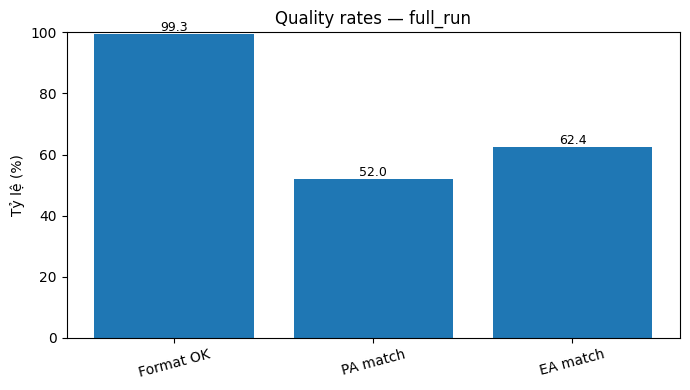

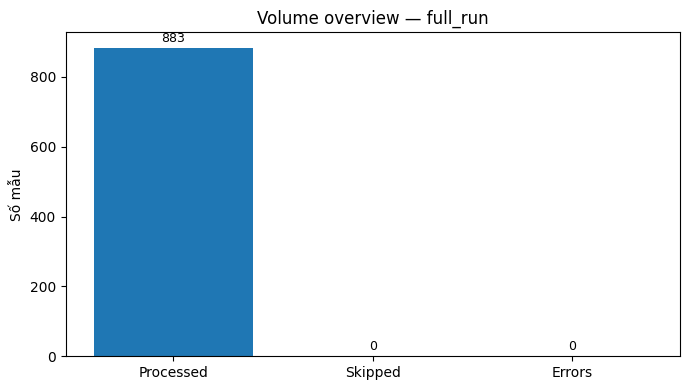

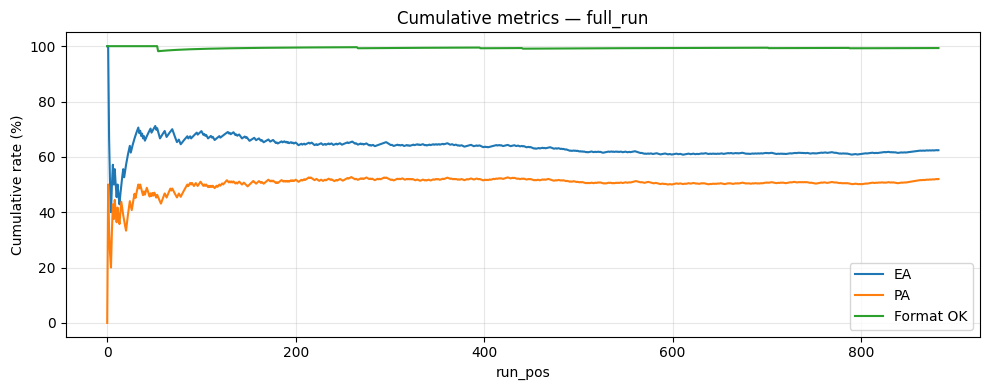

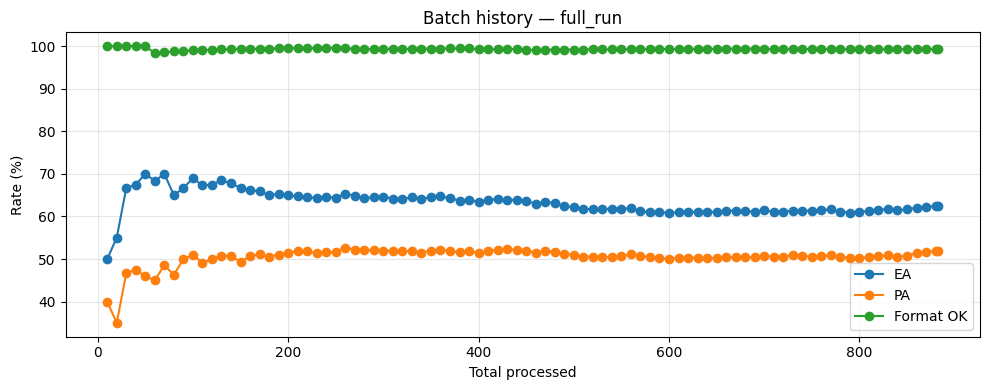

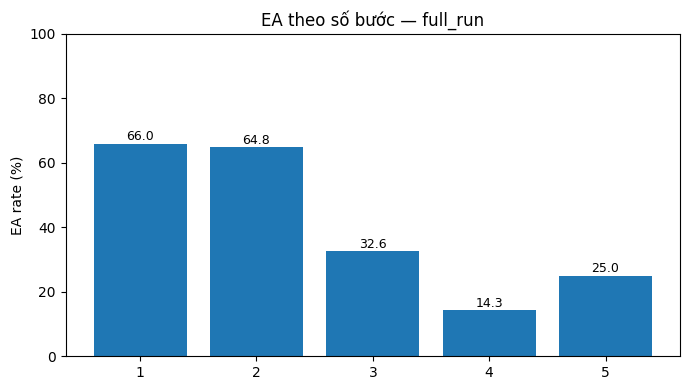

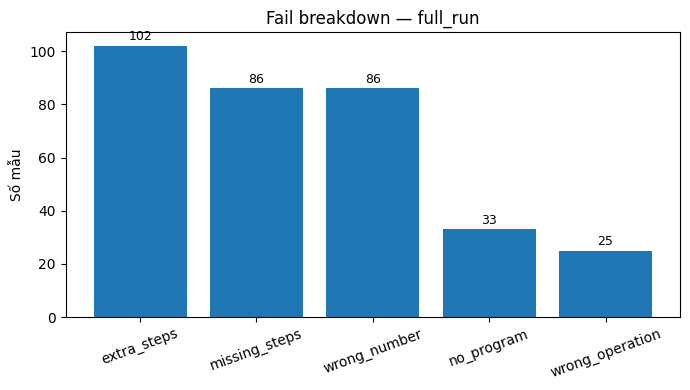

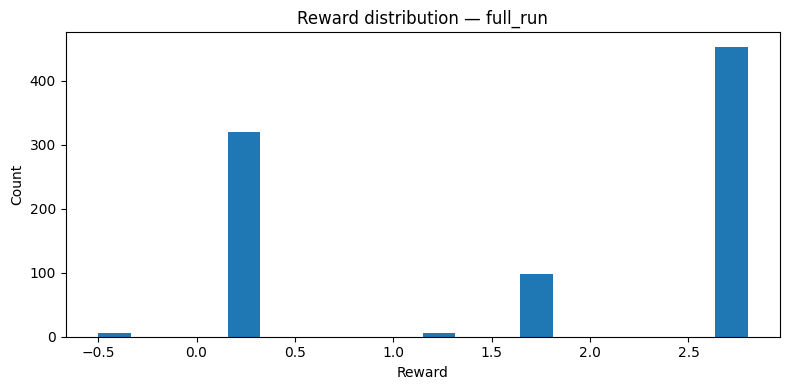

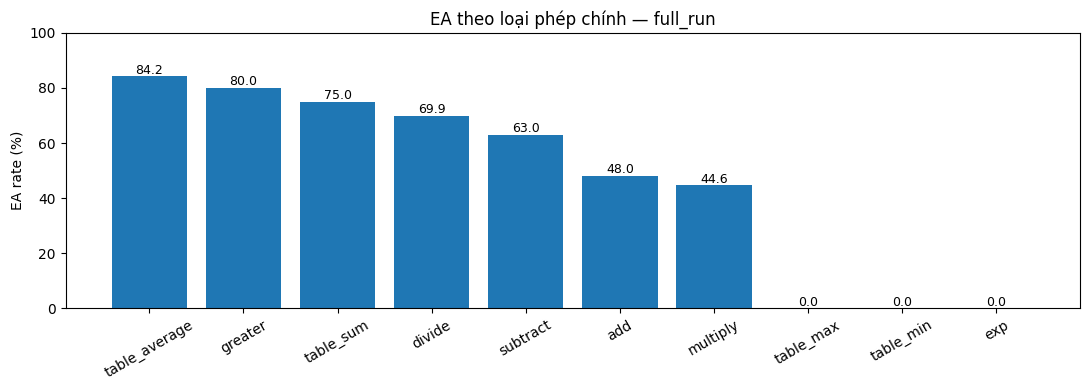


FULL [full_run]
  Records      : 883
  Processed    : 883
  Skipped      : 0 (0.0%)
  Errors       : 0 (0.0%)
  Format OK    : 99.3%
  PA match     : 52.0%
  EA match     : 62.4%
  Truncated    : 0.1%
  Avg reward   : 1.7504

[SAVE] Artifacts đã lưu tại: /content/drive/MyDrive/coldstart_data/qwen3_8b/viz_full_run
[SAVE] Summary JSON : /content/drive/MyDrive/coldstart_data/qwen3_8b/viz_full_run/summary.json
[SAVE] Report TXT   : /content/drive/MyDrive/coldstart_data/qwen3_8b/viz_full_run/report_notes.txt
[SAVE] All records  : /content/drive/MyDrive/coldstart_data/qwen3_8b/viz_full_run/all_records.csv
[SAVE] Fail cases   : /content/drive/MyDrive/coldstart_data/qwen3_8b/viz_full_run/fail_cases.csv


In [ ]:
# ============================================================
# CELL 6: INFERENCE + AUTO-RESUME + REPORT / VISUALIZATION
# ============================================================
import time, json, os, glob, shutil, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

try:
    from IPython.display import display
except ImportError:
    display = print

# ══════════════════════════════════════════════════════════════
# CONFIG — CHỈ SỬA PHẦN NÀY
# ══════════════════════════════════════════════════════════════
PILOT_MODE  = False         # True = pilot | False = full dataset
PILOT_SIZE  = 100            # số mẫu pilot thực tế
CLEAN_OLD   = False         # chỉ xóa dữ liệu pilot cũ khi PILOT_MODE=True
BATCH_SIZE  = 10             # lưu Drive mỗi N mẫu
INFER_BATCH = 10             # số prompt mỗi lần gọi vLLM
MAX_PROMPT_TOKENS = 3500     # bỏ qua prompt dài hơn ngưỡng này
# ══════════════════════════════════════════════════════════════

RUN_TAG = "pilot_v1" if PILOT_MODE else "full_run"

# ── Run-specific paths (không cần sửa Cell 2) ───────────────
CHUNK_DIR        = os.path.join(OUTPUT_DIR, f"chunks_{RUN_TAG}")
PROGRESS_PATH    = os.path.join(OUTPUT_DIR, f"progress_{RUN_TAG}.json")
HISTORY_PATH     = os.path.join(OUTPUT_DIR, f"history_{RUN_TAG}.jsonl")
FINAL_CHUNK_PATH = os.path.join(CHUNK_DIR, "chunk_final.json")
VIZ_DIR          = os.path.join(OUTPUT_DIR, f"viz_{RUN_TAG}")

SUMMARY_PATH       = os.path.join(VIZ_DIR, "summary.json")
REPORT_TXT_PATH    = os.path.join(VIZ_DIR, "report_notes.txt")
ALL_RECORDS_CSV    = os.path.join(VIZ_DIR, "all_records.csv")
FAIL_CASES_CSV     = os.path.join(VIZ_DIR, "fail_cases.csv")
STEP_STATS_CSV     = os.path.join(VIZ_DIR, "ea_by_steps.csv")
OP_STATS_CSV       = os.path.join(VIZ_DIR, "ea_by_main_op.csv")
FAIL_BREAKDOWN_CSV = os.path.join(VIZ_DIR, "fail_breakdown.csv")
SKIP_BREAKDOWN_CSV = os.path.join(VIZ_DIR, "skip_breakdown.csv")
HISTORY_CSV        = os.path.join(VIZ_DIR, "history_curve.csv")

OPS_PATTERN = r'(add|subtract|multiply|divide|greater|exp|table_\w+)\('

# ── Helpers ──────────────────────────────────────────────────
def _pick(pool, n):
    n = min(n, len(pool))
    return list(np.random.choice(pool, n, replace=False)) if n > 0 else []

def _chunk_sort_key(path):
    name = os.path.splitext(os.path.basename(path))[0]
    # Đọc chunk_final trước để chunk_N mới hơn sẽ override nếu bị trùng run_pos
    if name == "chunk_final":
        return -1
    m = re.search(r'chunk_(\d+)$', name)
    return int(m.group(1)) if m else 10**18

def _load_records(chunk_dir):
    paths = glob.glob(os.path.join(chunk_dir, "chunk_*.json"))
    if not paths:
        return []

    by_key = {}
    for path in sorted(paths, key=_chunk_sort_key):
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[WARN] Không đọc được {path}: {e}")
            continue

        if isinstance(data, dict):
            data = [data]
        if not isinstance(data, list):
            continue

        for row in data:
            if not isinstance(row, dict):
                continue
            key = row.get("run_pos", row.get("idx"))
            if key is None:
                continue
            by_key[int(key)] = row

    return [by_key[k] for k in sorted(by_key)]

def _calc_stats_from_records(records):
    stats = {
        "total": 0,
        "ea_match": 0,
        "pa_match": 0,
        "format_ok": 0,
        "errors": 0,
        "skipped": 0,
    }
    total_saved = 0
    last_run_pos = -1

    for r in records:
        run_pos = r.get("run_pos")
        if run_pos is not None:
            last_run_pos = max(last_run_pos, int(run_pos))

        is_skipped = bool(r.get("skipped", False))
        if is_skipped:
            stats["skipped"] += 1
        else:
            stats["total"] += 1
            stats["ea_match"] += int(bool(r.get("ea_match", False)))
            stats["pa_match"] += int(bool(r.get("pa_match", False)))
            stats["format_ok"] += int(bool(r.get("has_format", False)))

        stats["errors"] += int(bool(r.get("error_flag", False)))
        total_saved += int(bool(r.get("ea_match", False)))

    return stats, total_saved, last_run_pos

def _build_snapshot(last_run_pos, last_source_idx, stats, total_saved, completed=False):
    denom = max(stats["total"], 1)
    return {
        "ts": time.strftime("%Y-%m-%d %H:%M:%S"),
        "run_tag": RUN_TAG,
        "last_processed_idx": int(last_run_pos),
        "last_processed_global_idx": int(last_source_idx),
        "last_processed_source_idx": int(last_source_idx),
        "total_processed": int(stats["total"]),
        "total_saved": int(total_saved),
        "ea_count": int(stats["ea_match"]),
        "pa_count": int(stats["pa_match"]),
        "format_ok_count": int(stats["format_ok"]),
        "errors": int(stats["errors"]),
        "skipped": int(stats["skipped"]),
        "ea_rate": float(stats["ea_match"] / denom),
        "pa_rate": float(stats["pa_match"] / denom),
        "fmt_rate": float(stats["format_ok"] / denom),
        "completed": bool(completed),
    }

def _append_history(snapshot):
    with open(HISTORY_PATH, "a", encoding="utf-8") as f:
        f.write(json.dumps(snapshot, ensure_ascii=False) + "\n")

def _save_chunk(chunk, actual_idx, source_idx, stats, total_saved, completed=False):
    chunk_idx = actual_idx // BATCH_SIZE
    chunk_path = os.path.join(CHUNK_DIR, f"chunk_{chunk_idx:05d}.json")

    with open(chunk_path, "w", encoding="utf-8") as f:
        json.dump(chunk, f, ensure_ascii=False, indent=2)

    snapshot = _build_snapshot(
        last_run_pos=actual_idx,
        last_source_idx=source_idx,
        stats=stats,
        total_saved=total_saved,
        completed=completed,
    )

    with open(PROGRESS_PATH, "w", encoding="utf-8") as f:
        json.dump(snapshot, f, ensure_ascii=False, indent=2)

    _append_history(snapshot)

def _to_float(x):
    if x is None or x == "":
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    s = str(x).strip().replace(",", "")
    try:
        return float(s)
    except Exception:
        return np.nan

def _count_steps(prog):
    if not isinstance(prog, str):
        return np.nan
    return len(re.findall(OPS_PATTERN, prog))

def _get_main_op(prog):
    if not isinstance(prog, str):
        return "unknown"
    ops = re.findall(OPS_PATTERN, prog)
    if not ops:
        return "unknown"
    if "greater" in ops:
        return "greater"
    if "exp" in ops:
        return "exp"
    return ops[0]

def _classify_error(row):
    if bool(row.get("skipped", False)):
        return row.get("skip_reason") or "skipped"
    if bool(row.get("ea_match", False)):
        return "pass"

    pred_prog = row.get("pred_prog")
    gold_prog = row.get("gold_prog") or ""

    if not pred_prog:
        return "no_program"

    pred_ops = re.findall(OPS_PATTERN, str(pred_prog))
    gold_ops = re.findall(OPS_PATTERN, str(gold_prog))

    if len(pred_ops) > len(gold_ops):
        return "extra_steps"
    if len(pred_ops) < len(gold_ops):
        return "missing_steps"
    if pred_ops != gold_ops:
        return "wrong_operation"
    return "wrong_number"

def _save_bar_plot(labels, values, title, ylabel, save_path, ylim=None, rotation=0):
    if len(labels) == 0:
        return
    plt.figure(figsize=(max(7, len(labels) * 1.1), 4))
    plt.bar(labels, values)
    top = 0 if len(values) == 0 else max(values)
    offset = 1 if ylim is not None and ylim[1] <= 100 else max(top * 0.02, 0.2)
    for i, v in enumerate(values):
        if pd.notna(v):
            plt.text(i, v + offset, f"{v:.1f}" if isinstance(v, (float, np.floating)) else str(v), ha="center", fontsize=9)
    plt.title(title)
    plt.ylabel(ylabel)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()

# ── Xóa dữ liệu pilot cũ ─────────────────────────────────────
if PILOT_MODE and CLEAN_OLD:
    for f in glob.glob(f"{OUTPUT_DIR}/progress_pilot*.json"):
        os.remove(f)
        print(f"[CLEAN] Xóa {f}")
    for f in glob.glob(f"{OUTPUT_DIR}/history_pilot*.jsonl"):
        os.remove(f)
        print(f"[CLEAN] Xóa {f}")
    for d in glob.glob(f"{OUTPUT_DIR}/chunks_pilot*"):
        shutil.rmtree(d, ignore_errors=True)
        print(f"[CLEAN] Xóa {d}")
    for d in glob.glob(f"{OUTPUT_DIR}/viz_pilot*"):
        shutil.rmtree(d, ignore_errors=True)
        print(f"[CLEAN] Xóa {d}")

os.makedirs(CHUNK_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

# ── Chọn mẫu ─────────────────────────────────────────────────
if PILOT_MODE:
    np.random.seed(42)

    step_counts = []
    for s in train_valid:
        prog = s["qa"]["program"]
        n_ops = len(re.findall(OPS_PATTERN, prog))
        step_counts.append(n_ops)

    idx_1step = [i for i, n in enumerate(step_counts) if n == 1]
    idx_2step = [i for i, n in enumerate(step_counts) if n == 2]
    idx_3plus = [i for i, n in enumerate(step_counts) if n >= 3]

    reserve_slots = min(5, PILOT_SIZE)
    base_target = max(PILOT_SIZE - reserve_slots, 0)

    n1 = min(int(round(base_target * 0.60)), len(idx_1step))
    n2 = min(int(round(base_target * 0.30)), len(idx_2step))
    n3 = min(base_target - n1 - n2, len(idx_3plus))

    pilot_set = set(_pick(idx_1step, n1) + _pick(idx_2step, n2) + _pick(idx_3plus, n3))

    coverage_rules = [("greater(", 1), ("exp(", 1), ("const_", 3)]
    for keyword, target in coverage_rules:
        current = sum(1 for i in pilot_set if keyword in train_valid[i]["qa"]["program"])
        need = max(0, target - current)
        if need > 0:
            pool = [i for i, s in enumerate(train_valid) if keyword in s["qa"]["program"] and i not in pilot_set]
            pilot_set.update(_pick(pool, need))

    if len(pilot_set) < PILOT_SIZE:
        rest_pool = [i for i in range(len(train_valid)) if i not in pilot_set]
        pilot_set.update(_pick(rest_pool, PILOT_SIZE - len(pilot_set)))

    pilot_indices = sorted(list(pilot_set))
    if len(pilot_indices) > PILOT_SIZE:
        pilot_indices = pilot_indices[:PILOT_SIZE]

    samples = [train_valid[i] for i in pilot_indices]
    source_indices = pilot_indices

    print(f"[PILOT] {len(samples)} mẫu stratified")
    step_dist = Counter(step_counts[i] for i in pilot_indices)
    for k in sorted(step_dist):
        print(f"  {k}-step: {step_dist[k]}")
    print(
        f"  greater: {sum(1 for i in pilot_indices if 'greater(' in train_valid[i]['qa']['program'])}"
        f" | exp: {sum(1 for i in pilot_indices if 'exp(' in train_valid[i]['qa']['program'])}"
        f" | const_*: {sum(1 for i in pilot_indices if 'const_' in train_valid[i]['qa']['program'])}"
    )
else:
    samples = train_valid
    source_indices = list(range(len(train_valid)))
    print(f"[FULL] {len(samples)} mẫu")

# ── Resume từ chunk/progress cũ ──────────────────────────────
existing_records = _load_records(CHUNK_DIR)
stats, total_saved, last_existing_run_pos = _calc_stats_from_records(existing_records)

resume_from = 0
if os.path.exists(PROGRESS_PATH):
    with open(PROGRESS_PATH, "r", encoding="utf-8") as f:
        progress = json.load(f)

    progress_completed = bool(progress.get("completed", False))
    progress_last_idx = int(progress.get("last_processed_idx", -1))

    if progress_completed and len(existing_records) < len(samples):
        print("[WARN] Progress báo completed nhưng record chưa đủ. Resume theo chunk cũ.")
        resume_from = last_existing_run_pos + 1
    elif progress_completed:
        print(f"[RESUME] '{RUN_TAG}' đã hoàn tất.")
        resume_from = len(samples)
        total_saved = max(total_saved, int(progress.get("total_saved", 0)))
    else:
        resume_from = max(progress_last_idx, last_existing_run_pos) + 1
        total_saved = max(total_saved, int(progress.get("total_saved", 0)))
        print(f"[RESUME] Tiếp tục từ run_pos #{resume_from}, đã có {total_saved} EA-match")
elif last_existing_run_pos >= 0:
    resume_from = last_existing_run_pos + 1
    print(f"[RESUME] Không thấy progress nhưng có chunk cũ. Tiếp tục từ run_pos #{resume_from}")
else:
    print(f"[RESUME] Bắt đầu từ đầu. {len(samples)} mẫu")

resume_from = min(resume_from, len(samples))
remaining = samples[resume_from:]
remaining_source_indices = source_indices[resume_from:]

if existing_records:
    print(
        f"[RESUME] Loaded {len(existing_records)} record cũ"
        f" | processed={stats['total']}"
        f" | skipped={stats['skipped']}"
        f" | errors={stats['errors']}"
        f" | saved={total_saved}"
    )

print(f"[INFO] Còn {len(remaining)} mẫu cần xử lý")

# ══════════════════════════════════════════════════════════════
# INFERENCE
# ══════════════════════════════════════════════════════════════
if len(remaining) == 0:
    print("[INFO] Không còn mẫu nào cần xử lý. Sẽ dựng report từ dữ liệu đã lưu.")
else:
    if os.path.exists(FINAL_CHUNK_PATH):
        os.remove(FINAL_CHUNK_PATH)

    # ── Build prompts ────────────────────────────────────────
    print("[PROMPT] Build prompts...")
    items = []

    for rel_pos, (sample, source_idx) in enumerate(zip(remaining, remaining_source_indices)):
        actual_idx = resume_from + rel_pos
        item = {
            "sample": sample,
            "run_pos": int(actual_idx),
            "source_idx": int(source_idx),
            "prompt": None,
            "prompt_tokens": np.nan,
            "output": None,
            "skip_reason": None,
            "error_flag": False,
            "error_stage": None,
            "error_message": None,
        }

        try:
            p = build_prompt(sample)
            tok_count = len(tokenizer.encode(p))
            item["prompt_tokens"] = int(tok_count)
            if tok_count > MAX_PROMPT_TOKENS:
                item["skip_reason"] = "prompt_too_long"
            else:
                item["prompt"] = p
        except Exception as e:
            item["skip_reason"] = "build_prompt_error"
            item["error_flag"] = True
            item["error_stage"] = "build_prompt"
            item["error_message"] = str(e)[:500]

        items.append(item)

    valid_prompt_count = sum(1 for x in items if x["prompt"] is not None)
    skipped_prompt_count = sum(1 for x in items if x["skip_reason"] is not None)
    build_error_count = sum(1 for x in items if x["error_stage"] == "build_prompt")
    print(
        f"[PROMPT] Hợp lệ={valid_prompt_count}"
        f" | skipped={skipped_prompt_count}"
        f" | build_errors={build_error_count}"
    )

    # ── Inference theo batch ─────────────────────────────────
    pbar = tqdm(total=len(items), desc="Inference", unit="mẫu")
    i = 0
    while i < len(items):
        batch_items = items[i:i + INFER_BATCH]
        valid_pos = [j for j, it in enumerate(batch_items) if it["prompt"] is not None]
        valid_prompts = [batch_items[j]["prompt"] for j in valid_pos]

        if valid_prompts:
            try:
                batch_out = model.fast_generate(valid_prompts, sampling_params=SAMPLING_PARAMS)
                for j, out in zip(valid_pos, batch_out):
                    batch_items[j]["output"] = out
            except Exception as e:
                msg = str(e)[:500]
                print(f"[LỖI] batch {i}–{i+len(batch_items)}: {msg}")
                for j in valid_pos:
                    batch_items[j]["skip_reason"] = "inference_error"
                    batch_items[j]["error_flag"] = True
                    batch_items[j]["error_stage"] = "inference"
                    batch_items[j]["error_message"] = msg

        i += INFER_BATCH
        pbar.update(len(batch_items))
    pbar.close()

    # ── Đánh giá + lưu ──────────────────────────────────────
    print("[EVAL] Đánh giá kết quả...")
    current_chunk = []
    pbar2 = tqdm(total=len(items), desc="Evaluate", unit="mẫu")

    for item in items:
        sample = item["sample"]
        actual_idx = item["run_pos"]
        source_idx = item["source_idx"]

        # Skip / error trước inference hoặc lỗi batch inference
        if item["prompt"] is None or item["output"] is None:
            stats["skipped"] += 1
            if item["error_flag"]:
                stats["errors"] += 1

            record = {
                "run_tag": RUN_TAG,
                "run_pos": int(actual_idx),
                "idx": int(source_idx),  # source idx gốc trong train_valid
                "question": sample["qa"]["question"] if sample else None,
                "gold_prog": sample["qa"]["program"] if sample else None,
                "exe_ans": sample["qa"].get("exe_ans") if sample else None,
                "pred_text": None,
                "pred_prog": None,
                "ea_match": False,
                "pa_match": False,
                "has_format": False,
                "reward": -1.0,
                "pred_val": None,
                "gold_val": None,
                "prompt_tokens": item["prompt_tokens"],
                "skipped": True,
                "skip_reason": item["skip_reason"] or "unknown",
                "error_flag": bool(item["error_flag"]),
                "error_stage": item["error_stage"],
                "error_message": item["error_message"],
            }
            current_chunk.append(record)
            pbar2.update(1)

            if len(current_chunk) >= BATCH_SIZE:
                _save_chunk(current_chunk, actual_idx, source_idx, stats, total_saved, completed=False)
                current_chunk = []
            continue

        if hasattr(item["output"], "outputs") and len(item["output"].outputs) > 0:
            pred_text = item["output"].outputs[0].text
        else:
            pred_text = str(item["output"])

        gold_prog = sample["qa"]["program"]
        table = sample.get("table", [])
        exe_ans = sample["qa"].get("exe_ans")

        error_flag = bool(item["error_flag"])
        error_stage = item["error_stage"]
        error_message = item["error_message"]

        try:
            eval_result = compute_reward(pred_text, gold_prog, table, exe_ans=exe_ans)
        except Exception as e:
            eval_result = {
                "reward": -0.3,
                "ea_match": False,
                "pa_match": False,
                "has_format": False,
                "pred_prog": None,
                "pred_val": None,
                "gold_val": None,
            }
            error_flag = True
            error_stage = "compute_reward"
            error_message = str(e)[:500]

        stats["total"] += 1
        stats["ea_match"] += int(bool(eval_result["ea_match"]))
        stats["pa_match"] += int(bool(eval_result["pa_match"]))
        stats["format_ok"] += int(bool(eval_result["has_format"]))
        stats["errors"] += int(error_flag)

        if bool(eval_result["ea_match"]):
            total_saved += 1

        record = {
            "run_tag": RUN_TAG,
            "run_pos": int(actual_idx),
            "idx": int(source_idx),  # source idx gốc trong train_valid
            "question": sample["qa"]["question"],
            "gold_prog": gold_prog,
            "exe_ans": exe_ans,
            "pred_text": pred_text,
            "pred_prog": eval_result.get("pred_prog"),
            "ea_match": bool(eval_result["ea_match"]),
            "pa_match": bool(eval_result["pa_match"]),
            "has_format": bool(eval_result["has_format"]),
            "reward": eval_result["reward"],
            "pred_val": eval_result.get("pred_val"),
            "gold_val": eval_result.get("gold_val"),
            "prompt_tokens": item["prompt_tokens"],
            "skipped": False,
            "skip_reason": None,
            "error_flag": error_flag,
            "error_stage": error_stage,
            "error_message": error_message,
        }
        current_chunk.append(record)

        pbar2.update(1)
        if len(current_chunk) >= BATCH_SIZE:
            _save_chunk(current_chunk, actual_idx, source_idx, stats, total_saved, completed=False)
            current_chunk = []
            pbar2.set_postfix({
                "EA%": f"{stats['ea_match'] / max(stats['total'], 1) * 100:.1f}",
                "saved": total_saved
            })

    # Lưu chunk cuối
    if current_chunk:
        with open(FINAL_CHUNK_PATH, "w", encoding="utf-8") as f:
            json.dump(current_chunk, f, ensure_ascii=False, indent=2)
    elif os.path.exists(FINAL_CHUNK_PATH):
        os.remove(FINAL_CHUNK_PATH)

    pbar2.close()

    # Ghi progress hoàn tất
    last_idx = resume_from + len(items) - 1 if items else resume_from - 1
    if 0 <= last_idx < len(source_indices):
        last_source_idx = int(source_indices[last_idx])
    else:
        last_source_idx = -1

    final_snapshot = _build_snapshot(
        last_run_pos=last_idx,
        last_source_idx=last_source_idx,
        stats=stats,
        total_saved=total_saved,
        completed=(resume_from + len(items) >= len(samples))
    )

    with open(PROGRESS_PATH, "w", encoding="utf-8") as f:
        json.dump(final_snapshot, f, ensure_ascii=False, indent=2)

    _append_history(final_snapshot)

# Nếu không còn remaining mà record đã đủ, vẫn chốt progress completed
records_after_run = _load_records(CHUNK_DIR)
if len(remaining) == 0 and len(records_after_run) == len(samples) and len(samples) > 0:
    stats, total_saved, last_existing_run_pos = _calc_stats_from_records(records_after_run)
    last_source_idx = int(source_indices[-1]) if len(source_indices) else -1
    final_snapshot = _build_snapshot(
        last_run_pos=len(samples) - 1,
        last_source_idx=last_source_idx,
        stats=stats,
        total_saved=total_saved,
        completed=True
    )
    with open(PROGRESS_PATH, "w", encoding="utf-8") as f:
        json.dump(final_snapshot, f, ensure_ascii=False, indent=2)

# ══════════════════════════════════════════════════════════════
# REPORT + VISUALIZATION
# ══════════════════════════════════════════════════════════════
print("\n[REPORT] Tạo summary + visualization...")

records = _load_records(CHUNK_DIR)
if not records:
    print("[REPORT] Chưa có record nào để phân tích.")
else:
    df = pd.DataFrame(records)

    if "run_pos" not in df.columns:
        df["run_pos"] = np.arange(len(df))
    if "idx" not in df.columns:
        df["idx"] = df["run_pos"]

    df = df.sort_values(["run_pos", "idx"]).reset_index(drop=True)

    # Bù cột thiếu để tương thích với record cũ
    for col in ["ea_match", "pa_match", "has_format", "skipped", "error_flag"]:
        if col not in df.columns:
            df[col] = False
        df[col] = df[col].fillna(False).astype(bool)

    for col in ["pred_text", "pred_prog", "gold_prog", "question", "skip_reason", "error_stage", "error_message"]:
        if col not in df.columns:
            df[col] = None

    for col in ["reward", "pred_val", "gold_val", "prompt_tokens"]:
        if col not in df.columns:
            df[col] = np.nan

    df["reward"] = pd.to_numeric(df["reward"], errors="coerce")
    df["prompt_tokens"] = pd.to_numeric(df["prompt_tokens"], errors="coerce")
    df["pred_val_num"] = df["pred_val"].apply(_to_float)
    df["gold_val_num"] = df["gold_val"].apply(_to_float)
    df["abs_value_error"] = (df["pred_val_num"] - df["gold_val_num"]).abs()

    df["n_steps"] = df["gold_prog"].apply(_count_steps)
    df["main_op"] = df["gold_prog"].apply(_get_main_op)
    df["truncated"] = df["pred_text"].fillna("").map(lambda x: x.count("```") % 2 == 1)
    df["error_type"] = df.apply(_classify_error, axis=1)

    processed = df[~df["skipped"]].copy()
    failed = processed[~processed["ea_match"]].copy()
    skipped_df = df[df["skipped"]].copy()
    error_df = df[df["error_flag"]].copy()

    processed_n = len(processed)
    total_n = len(df)

    fmt_rate_pct = round(float(processed["has_format"].mean() * 100), 2) if processed_n else 0.0
    pa_rate_pct = round(float(processed["pa_match"].mean() * 100), 2) if processed_n else 0.0
    ea_rate_pct = round(float(processed["ea_match"].mean() * 100), 2) if processed_n else 0.0
    trunc_rate_pct = round(float(processed["truncated"].mean() * 100), 2) if processed_n else 0.0
    skipped_rate_pct = round(float(skipped_df.shape[0] / max(total_n, 1) * 100), 2)
    error_rate_pct = round(float(error_df.shape[0] / max(total_n, 1) * 100), 2)

    quality_rates = pd.DataFrame({
        "metric": ["Format OK", "PA match", "EA match"],
        "value_pct": [fmt_rate_pct, pa_rate_pct, ea_rate_pct]
    })

    volume_stats = pd.DataFrame({
        "metric": ["Processed", "Skipped", "Errors"],
        "count": [processed_n, int(skipped_df.shape[0]), int(error_df.shape[0])]
    })

    step_stats = pd.DataFrame(columns=["n_steps", "total", "ea", "pa", "fmt", "ea_rate", "pa_rate", "fmt_rate"])
    if processed_n:
        step_stats = processed.groupby("n_steps", dropna=False).agg(
            total=("run_pos", "count"),
            ea=("ea_match", "sum"),
            pa=("pa_match", "sum"),
            fmt=("has_format", "sum"),
        ).reset_index()
        step_stats["ea_rate"] = step_stats["ea"] / step_stats["total"] * 100
        step_stats["pa_rate"] = step_stats["pa"] / step_stats["total"] * 100
        step_stats["fmt_rate"] = step_stats["fmt"] / step_stats["total"] * 100

    op_stats = pd.DataFrame(columns=["main_op", "total", "ea", "ea_rate"])
    if processed_n:
        op_stats = processed.groupby("main_op").agg(
            total=("run_pos", "count"),
            ea=("ea_match", "sum"),
        ).reset_index()
        op_stats["ea_rate"] = op_stats["ea"] / op_stats["total"] * 100
        op_stats = op_stats.sort_values(["ea_rate", "total"], ascending=[False, False])

    fail_breakdown = pd.DataFrame(columns=["error_type", "count"])
    if len(failed):
        fail_breakdown = failed["error_type"].value_counts().rename_axis("error_type").reset_index(name="count")

    skip_breakdown = pd.DataFrame(columns=["skip_reason", "count"])
    if len(skipped_df):
        skip_breakdown = skipped_df["skip_reason"].fillna("unknown").value_counts().rename_axis("skip_reason").reset_index(name="count")

    action_items = []
    if processed_n and trunc_rate_pct > 5:
        action_items.append("Tăng max_tokens vì output đang bị cắt.")
    if len(skipped_df[skipped_df["skip_reason"] == "prompt_too_long"]) > 0:
        action_items.append("Prompt quá dài; cần rút context hoặc giảm few-shot.")
    if len(failed[failed["error_type"] == "no_program"]) >= 3:
        action_items.append("Nhiều mẫu không extract được program; siết format output.")
    if len(failed[failed["error_type"] == "wrong_operation"]) >= 3:
        action_items.append("Sai loại phép; cần thêm ví dụ/constraint về chọn operator.")
    if len(failed[failed["error_type"] == "missing_steps"]) >= 3:
        action_items.append("Thiếu bước; nhấn mạnh decomposition nhiều bước.")
    if len(failed[failed["error_type"] == "wrong_number"]) >= 3:
        action_items.append("Khung phép đúng nhưng sai số; kiểm tra parse số và execution trace.")
    if PILOT_MODE:
        if ea_rate_pct >= 60:
            action_items.append("Pilot đủ ổn để cân nhắc chạy full.")
        elif ea_rate_pct >= 40:
            action_items.append("EA tạm được nhưng chưa đủ sạch; nên chỉnh prompt thêm một vòng.")
        else:
            action_items.append("EA còn yếu; chạy full lúc này là phí GPU.")
    if not action_items:
        action_items.append("Chưa có lỗi áp đảo; nên so sánh thêm nhiều RUN_TAG để chọn prompt tốt nhất.")

    summary = {
        "run_tag": RUN_TAG,
        "mode": "pilot" if PILOT_MODE else "full",
        "total_records": int(total_n),
        "processed": int(processed_n),
        "skipped": int(skipped_df.shape[0]),
        "errors": int(error_df.shape[0]),
        "ea_match_count": int(processed["ea_match"].sum()) if processed_n else 0,
        "pa_match_count": int(processed["pa_match"].sum()) if processed_n else 0,
        "format_ok_count": int(processed["has_format"].sum()) if processed_n else 0,
        "ea_rate_pct": ea_rate_pct,
        "pa_rate_pct": pa_rate_pct,
        "fmt_rate_pct": fmt_rate_pct,
        "truncated_count": int(processed["truncated"].sum()) if processed_n else 0,
        "truncated_rate_pct": trunc_rate_pct,
        "skipped_rate_pct": skipped_rate_pct,
        "error_rate_pct": error_rate_pct,
        "avg_reward": round(float(processed["reward"].dropna().mean()), 4) if processed["reward"].notna().any() else None,
        "median_reward": round(float(processed["reward"].dropna().median()), 4) if processed["reward"].notna().any() else None,
        "avg_prompt_tokens": round(float(processed["prompt_tokens"].dropna().mean()), 2) if processed["prompt_tokens"].notna().any() else None,
        "avg_abs_value_error": round(float(failed["abs_value_error"].dropna().mean()), 4) if failed["abs_value_error"].notna().any() else None,
        "action_items": action_items,
    }

    # ── Save machine-readable outputs ────────────────────────
    with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    fail_cols = [
        "run_pos", "idx", "n_steps", "main_op", "error_type", "question",
        "gold_prog", "pred_prog", "pred_val", "gold_val", "reward",
        "prompt_tokens", "skip_reason", "error_stage", "error_message"
    ]
    fail_view = failed[fail_cols].copy() if len(failed) else pd.DataFrame(columns=fail_cols)

    df.to_csv(ALL_RECORDS_CSV, index=False, encoding="utf-8-sig")
    fail_view.to_csv(FAIL_CASES_CSV, index=False, encoding="utf-8-sig")
    step_stats.to_csv(STEP_STATS_CSV, index=False, encoding="utf-8-sig")
    op_stats.to_csv(OP_STATS_CSV, index=False, encoding="utf-8-sig")
    fail_breakdown.to_csv(FAIL_BREAKDOWN_CSV, index=False, encoding="utf-8-sig")
    skip_breakdown.to_csv(SKIP_BREAKDOWN_CSV, index=False, encoding="utf-8-sig")

    report_lines = [
        f"RUN_TAG: {RUN_TAG}",
        f"MODE: {'PILOT' if PILOT_MODE else 'FULL'}",
        f"TOTAL RECORDS: {total_n}",
        f"PROCESSED: {processed_n}",
        f"SKIPPED: {int(skipped_df.shape[0])}",
        f"ERRORS: {int(error_df.shape[0])}",
        f"FORMAT OK: {fmt_rate_pct:.2f}%",
        f"PA MATCH: {pa_rate_pct:.2f}%",
        f"EA MATCH: {ea_rate_pct:.2f}%",
        f"TRUNCATED: {trunc_rate_pct:.2f}%",
        f"AVG REWARD: {summary['avg_reward']}",
        f"AVG PROMPT TOKENS: {summary['avg_prompt_tokens']}",
        "",
        "ACTION ITEMS:",
    ] + [f"- {x}" for x in action_items]

    with open(REPORT_TXT_PATH, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))

    # ── Hiển thị nhanh trong notebook ────────────────────────
    summary_df = pd.DataFrame([
        {"metric": "Total records", "value": total_n},
        {"metric": "Processed", "value": processed_n},
        {"metric": "Skipped", "value": int(skipped_df.shape[0])},
        {"metric": "Errors", "value": int(error_df.shape[0])},
        {"metric": "Format OK (%)", "value": fmt_rate_pct},
        {"metric": "PA match (%)", "value": pa_rate_pct},
        {"metric": "EA match (%)", "value": ea_rate_pct},
        {"metric": "Truncated (%)", "value": trunc_rate_pct},
    ])
    display(summary_df)
    display(quality_rates)
    if len(step_stats):
        display(step_stats.round(2))
    if len(op_stats):
        display(op_stats.round(2))
    if len(fail_view):
        display(fail_view.head(20))

    # ── Plot 1: quality rates ────────────────────────────────
    _save_bar_plot(
        labels=quality_rates["metric"].tolist(),
        values=quality_rates["value_pct"].tolist(),
        title=f"Quality rates — {RUN_TAG}",
        ylabel="Tỷ lệ (%)",
        save_path=os.path.join(VIZ_DIR, "01_quality_rates.png"),
        ylim=(0, 100),
        rotation=15
    )

    # ── Plot 2: volume overview ──────────────────────────────
    _save_bar_plot(
        labels=volume_stats["metric"].tolist(),
        values=volume_stats["count"].tolist(),
        title=f"Volume overview — {RUN_TAG}",
        ylabel="Số mẫu",
        save_path=os.path.join(VIZ_DIR, "02_volume_overview.png"),
        rotation=0
    )

    # ── Plot 3: cumulative metrics theo run_pos ──────────────
    if processed_n:
        c = processed.sort_values("run_pos")[["run_pos", "ea_match", "pa_match", "has_format"]].copy()
        c["ea_cum"] = c["ea_match"].astype(int).expanding().mean() * 100
        c["pa_cum"] = c["pa_match"].astype(int).expanding().mean() * 100
        c["fmt_cum"] = c["has_format"].astype(int).expanding().mean() * 100

        plt.figure(figsize=(10, 4))
        plt.plot(c["run_pos"], c["ea_cum"], label="EA")
        plt.plot(c["run_pos"], c["pa_cum"], label="PA")
        plt.plot(c["run_pos"], c["fmt_cum"], label="Format OK")
        plt.xlabel("run_pos")
        plt.ylabel("Cumulative rate (%)")
        plt.title(f"Cumulative metrics — {RUN_TAG}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, "03_cumulative_metrics.png"), dpi=160, bbox_inches="tight")
        plt.show()

    # ── Plot 4: history curve theo batch-save ────────────────
    hist = pd.DataFrame()
    if os.path.exists(HISTORY_PATH):
        try:
            hist = pd.read_json(HISTORY_PATH, lines=True)
        except ValueError:
            hist = pd.DataFrame()

    if len(hist):
        hist = hist.sort_values(["last_processed_idx", "total_processed"]).drop_duplicates(
            subset=["last_processed_idx", "total_processed"], keep="last"
        )
        hist.to_csv(HISTORY_CSV, index=False, encoding="utf-8-sig")

        plt.figure(figsize=(10, 4))
        plt.plot(hist["total_processed"], hist["ea_rate"] * 100, marker="o", label="EA")
        plt.plot(hist["total_processed"], hist["pa_rate"] * 100, marker="o", label="PA")
        plt.plot(hist["total_processed"], hist["fmt_rate"] * 100, marker="o", label="Format OK")
        plt.xlabel("Total processed")
        plt.ylabel("Rate (%)")
        plt.title(f"Batch history — {RUN_TAG}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, "04_history_curve.png"), dpi=160, bbox_inches="tight")
        plt.show()
    else:
        print("[REPORT] Không có history để vẽ history curve.")

    # ── Plot 5: EA theo số bước ──────────────────────────────
    if len(step_stats):
        _save_bar_plot(
            labels=step_stats["n_steps"].astype(str).tolist(),
            values=step_stats["ea_rate"].tolist(),
            title=f"EA theo số bước — {RUN_TAG}",
            ylabel="EA rate (%)",
            save_path=os.path.join(VIZ_DIR, "05_ea_by_steps.png"),
            ylim=(0, 100),
            rotation=0
        )

    # ── Plot 6: fail breakdown ───────────────────────────────
    if len(fail_breakdown):
        _save_bar_plot(
            labels=fail_breakdown["error_type"].tolist(),
            values=fail_breakdown["count"].tolist(),
            title=f"Fail breakdown — {RUN_TAG}",
            ylabel="Số mẫu",
            save_path=os.path.join(VIZ_DIR, "06_fail_breakdown.png"),
            rotation=20
        )

    # ── Plot 7: reward distribution ──────────────────────────
    if processed["reward"].notna().any():
        plt.figure(figsize=(8, 4))
        plt.hist(processed["reward"].dropna(), bins=20)
        plt.xlabel("Reward")
        plt.ylabel("Count")
        plt.title(f"Reward distribution — {RUN_TAG}")
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, "07_reward_hist.png"), dpi=160, bbox_inches="tight")
        plt.show()

    # ── Plot 8: skip breakdown ───────────────────────────────
    if len(skip_breakdown):
        _save_bar_plot(
            labels=skip_breakdown["skip_reason"].tolist(),
            values=skip_breakdown["count"].tolist(),
            title=f"Skip breakdown — {RUN_TAG}",
            ylabel="Số mẫu",
            save_path=os.path.join(VIZ_DIR, "08_skip_breakdown.png"),
            rotation=20
        )

    # ── Plot 9: EA theo loại phép chính ──────────────────────
    if len(op_stats):
        _save_bar_plot(
            labels=op_stats["main_op"].tolist(),
            values=op_stats["ea_rate"].tolist(),
            title=f"EA theo loại phép chính — {RUN_TAG}",
            ylabel="EA rate (%)",
            save_path=os.path.join(VIZ_DIR, "09_ea_by_main_op.png"),
            ylim=(0, 100),
            rotation=30
        )

    # ── Tổng quan console ────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"{'PILOT' if PILOT_MODE else 'FULL'} [{RUN_TAG}]")
    print("=" * 60)
    print(f"  Records      : {total_n}")
    print(f"  Processed    : {processed_n}")
    print(f"  Skipped      : {int(skipped_df.shape[0])} ({skipped_rate_pct:.1f}%)")
    print(f"  Errors       : {int(error_df.shape[0])} ({error_rate_pct:.1f}%)")
    print(f"  Format OK    : {fmt_rate_pct:.1f}%")
    print(f"  PA match     : {pa_rate_pct:.1f}%")
    print(f"  EA match     : {ea_rate_pct:.1f}%")
    print(f"  Truncated    : {trunc_rate_pct:.1f}%")
    print(f"  Avg reward   : {summary['avg_reward']}")
    print("=" * 60)

    # ══════════════════════════════════════════════════════════
    # PILOT ANALYSIS
    # ══════════════════════════════════════════════════════════
    if PILOT_MODE:
        print("\n" + "=" * 65)
        print("  PILOT ANALYSIS")
        print("=" * 65)

        print(f"\n  [A] Output bị cắt cụt: {int(processed['truncated'].sum())}/{processed_n}")

        print(f"\n  [B] Lỗi ({len(failed)} fail):")
        if len(fail_breakdown):
            for _, row in fail_breakdown.iterrows():
                print(f"      {str(row['error_type']):<20s}: {int(row['count'])}")
        else:
            print("      Không có fail.")

        print(f"\n  [C] Fail cases đầu tiên (tối đa 10 mẫu):")
        print("=" * 65)
        if len(failed):
            for i, (_, r) in enumerate(failed.head(10).iterrows(), 1):
                pred_text = (r.get("pred_text") or "")
                pred_clean = re.sub(r'<think>.*?</think>', '', pred_text, flags=re.S).strip()
                if len(pred_clean) > 500:
                    pred_clean = pred_clean[:250] + "\n      [...]\n      " + pred_clean[-250:]

                print(f"\n  ── FAIL #{i} (run_pos={r['run_pos']}, source_idx={r['idx']}) ──")
                print(f"  Q: {r.get('question', '')}")
                print(f"  Gold program: {r.get('gold_prog')}")
                print(f"  Gold answer:  {r.get('exe_ans')}")
                print(f"  Pred program: {r.get('pred_prog', 'N/A')}")
                print(f"  Pred value:   {r.get('pred_val')}")
                print(f"  Gold value:   {r.get('gold_val')}")
                print(f"  Error type:   {r.get('error_type')}")
                print(f"  Format OK:    {r.get('has_format')}")
                print(f"  Output:")
                for line in pred_clean.split("\n"):
                    print(f"      {line}")
        else:
            print("  Không có fail.")

        passed = processed[processed["ea_match"]].copy()
        print(f"\n  [D] PASS ({len(passed)}) — 5 mẫu đầu:")
        print("=" * 65)
        if len(passed):
            for i, (_, r) in enumerate(passed.head(5).iterrows(), 1):
                print(f"\n  ── PASS #{i} (run_pos={r['run_pos']}, source_idx={r['idx']}) ──")
                print(f"  Q: {str(r.get('question',''))[:120]}")
                print(f"  Gold: {r.get('gold_prog')}")
                print(f"  Pred: {r.get('pred_prog')}")
                print(f"  Value: {r.get('pred_val')}")
        else:
            print("  Không có pass.")

        print(f"\n  [E] EA theo số bước:")
        if len(step_stats):
            for _, s in step_stats.sort_values("n_steps").iterrows():
                print(f"      {int(s['n_steps'])}-step: {int(s['ea'])}/{int(s['total'])} ({s['ea_rate']:.0f}%)")
        else:
            print("      Không có dữ liệu.")

        print(f"\n  [F] ACTION ITEMS:")
        print("=" * 65)
        for item in action_items:
            print(f"  - {item}")

    print(f"\n[SAVE] Artifacts đã lưu tại: {VIZ_DIR}")
    print(f"[SAVE] Summary JSON : {SUMMARY_PATH}")
    print(f"[SAVE] Report TXT   : {REPORT_TXT_PATH}")
    print(f"[SAVE] All records  : {ALL_RECORDS_CSV}")
    print(f"[SAVE] Fail cases   : {FAIL_CASES_CSV}")

In [ ]:
# @title Văn bản tiêu đề mặc định
# # ============================================================
# # CELL 6: INFERENCE + LƯU MỖI 10 MẪU (AUTO-RESUME)
# # ============================================================
# import time, json, os
# from tqdm.auto import tqdm

# # ── CONFIG CHO TỪNG NICK (CHỈ SỬA 3 DÒNG NÀY) ──────────────
# NICK_TAG  = "nick1_2501_3000"   # ← đổi theo nick
# START_IDX = 2501               # ← index bắt đầu (inclusive)
# END_IDX   = 3000             # ← index kết thúc (exclusive)
# # Nick 1: 0–499    | Nick 2: 500–999  | Nick 3: 1000–1499
# # Nick 4: 1500–1999| Nick 5: 2000–2499| Nick 6: 2500–2999
# # ─────────────────────────────────────────────────────────────

# BATCH_SIZE        = 10    # lưu Drive mỗi N mẫu
# INFER_BATCH       = 50    # số prompt mỗi lần gọi vLLM
# MAX_PROMPT_TOKENS = 3500  # bỏ qua prompt dài hơn ngưỡng này

# # Đường dẫn riêng cho từng nick
# CHUNK_DIR_NICK     = f"{OUTPUT_DIR}/chunks_{NICK_TAG}"
# PROGRESS_PATH_NICK = f"{OUTPUT_DIR}/progress_{NICK_TAG}.json"
# os.makedirs(CHUNK_DIR_NICK, exist_ok=True)

# # ── Hàm lưu chunk + progress ─────────────────────────────────
# def _save_chunk(chunk, actual_local_idx, global_idx):
#     chunk_idx  = actual_local_idx // BATCH_SIZE
#     chunk_path = os.path.join(CHUNK_DIR_NICK, f"chunk_{chunk_idx:05d}.json")
#     with open(chunk_path, "w", encoding="utf-8") as f:
#         json.dump(chunk, f, ensure_ascii=False, indent=2)
#     with open(PROGRESS_PATH_NICK, "w") as f:
#         json.dump({
#             "nick_tag":                  NICK_TAG,
#             "last_processed_local_idx":  actual_local_idx,
#             "last_processed_global_idx": global_idx,
#             "total_processed":           stats["total"],
#             "total_saved":               total_saved,
#             "ea_rate":  stats["ea_match"]  / max(stats["total"], 1),
#             "pa_rate":  stats["pa_match"]  / max(stats["total"], 1),
#             "fmt_rate": stats["format_ok"] / max(stats["total"], 1),
#         }, f, indent=2)

# # ── Slice dataset theo range của nick ────────────────────────
# nick_samples = train_valid[START_IDX:END_IDX]

# # ── Đọc tiến độ hiện tại ─────────────────────────────────────
# resume_from = 0
# total_saved = 0
# if os.path.exists(PROGRESS_PATH_NICK):
#     with open(PROGRESS_PATH_NICK) as f:
#         progress = json.load(f)
#     resume_from = progress["last_processed_local_idx"] + 1
#     total_saved = progress["total_saved"]
#     print(f"[RESUME] ▶ Tiếp tục từ local #{resume_from} (global #{START_IDX + resume_from})")
#     print(f"[RESUME] Đã có {total_saved} mẫu EA-match")
# else:
#     print(f"[RESUME] Bắt đầu từ đầu. Range: [{START_IDX}, {END_IDX})")

# remaining = nick_samples[resume_from:]
# print(f"[INFO] Còn {len(remaining)} mẫu cần xử lý")

# # ── Build toàn bộ prompts + lọc quá dài ──────────────────────
# print("[PROMPT] Build và kiểm tra độ dài prompts...")
# prompts       = []
# valid_samples = []
# skipped       = 0

# for s in remaining:
#     try:
#         p = build_prompt(s)
#         token_len = len(tokenizer.encode(p))
#         if token_len > MAX_PROMPT_TOKENS:
#             skipped += 1
#             prompts.append(None)
#             valid_samples.append(None)
#         else:
#             prompts.append(p)
#             valid_samples.append(s)
#     except Exception as e:
#         print(f"[WARN] build_prompt lỗi: {e}")
#         prompts.append(None)
#         valid_samples.append(None)

# print(f"[PROMPT] ✅ {len(prompts) - skipped} prompts hợp lệ | {skipped} bỏ qua (quá dài)")

# # ── Inference theo batch nhỏ ─────────────────────────────────
# stats = {"total": 0, "ea_match": 0, "pa_match": 0, "format_ok": 0, "errors": 0, "skipped": skipped}
# all_outputs = [None] * len(prompts)

# pbar = tqdm(total=len(prompts), desc="Inference", unit="mẫu")
# i = 0
# while i < len(prompts):
#     batch_p   = prompts[i : i + INFER_BATCH]
#     valid_idx = [j for j, p in enumerate(batch_p) if p is not None]
#     valid_p   = [batch_p[j] for j in valid_idx]

#     if valid_p:
#         try:
#             batch_out = model.fast_generate(valid_p, sampling_params=SAMPLING_PARAMS)
#             for j, out in zip(valid_idx, batch_out):
#                 all_outputs[i + j] = out
#         except Exception as e:
#             print(f"[LỖI INFERENCE] batch {i}–{i+len(batch_p)}: {e}")
#             stats["errors"] += len(valid_p)

#     i += INFER_BATCH
#     pbar.update(len(batch_p))

# pbar.close()

# # ── Đánh giá + lưu theo chunk ────────────────────────────────
# print("[EVAL] Đánh giá kết quả và lưu...")
# current_chunk = []

# pbar2 = tqdm(total=len(valid_samples), desc="Evaluate & Save", unit="mẫu")

# for local_idx, (sample, output) in enumerate(zip(valid_samples, all_outputs)):
#     actual_local_idx = resume_from + local_idx
#     global_idx       = START_IDX + actual_local_idx

#     if sample is None or output is None:
#         record = {
#             "idx": global_idx, "question": None, "gold_prog": None,
#             "pred_text": None, "pred_prog": None,
#             "ea_match": False, "pa_match": False, "has_format": False,
#             "reward": -1.0, "skipped": True,
#         }
#         current_chunk.append(record)
#         pbar2.update(1)
#         if len(current_chunk) >= BATCH_SIZE:
#             _save_chunk(current_chunk, actual_local_idx, global_idx)
#             current_chunk = []
#         continue

#     pred_text = output.outputs[0].text
#     gold_prog = sample["qa"]["program"]
#     table     = sample.get("table", [])

#     try:
#         eval_result = compute_reward(pred_text, gold_prog, table)
#     except Exception as e:
#         print(f"[WARN] compute_reward lỗi #{global_idx}: {e}")
#         eval_result = {"reward": -0.3, "ea_match": False,
#                        "pa_match": False, "has_format": False, "pred_prog": None}
#         stats["errors"] += 1

#     stats["total"]     += 1
#     stats["ea_match"]  += int(eval_result["ea_match"])
#     stats["pa_match"]  += int(eval_result["pa_match"])
#     stats["format_ok"] += int(eval_result["has_format"])
#     if eval_result["ea_match"]:
#         total_saved += 1

#     record = {
#         "idx":        global_idx,
#         "question":   sample["qa"]["question"],
#         "gold_prog":  gold_prog,
#         "pred_text":  pred_text,
#         "pred_prog":  eval_result["pred_prog"],
#         "ea_match":   eval_result["ea_match"],
#         "pa_match":   eval_result["pa_match"],
#         "has_format": eval_result["has_format"],
#         "reward":     eval_result["reward"],
#         "pred_val":   eval_result.get("pred_val"),
#         "gold_val":   eval_result.get("gold_val"),
#         "pre_text":   sample.get("pre_text", []),
#         "post_text":  sample.get("post_text", []),
#         "table":      table,
#         "skipped":    False,
#     }
#     current_chunk.append(record)
#     pbar2.update(1)

#     if len(current_chunk) >= BATCH_SIZE:
#         _save_chunk(current_chunk, actual_local_idx, global_idx)
#         current_chunk = []
#         pbar2.set_postfix({
#             "EA%": f"{stats['ea_match']/max(stats['total'],1)*100:.1f}",
#             "saved": total_saved
#         })

# # Lưu chunk còn lại
# if current_chunk:
#     chunk_path = os.path.join(CHUNK_DIR_NICK, "chunk_final.json")
#     with open(chunk_path, "w", encoding="utf-8") as f:
#         json.dump(current_chunk, f, ensure_ascii=False, indent=2)

# with open(PROGRESS_PATH_NICK, "w") as f:
#     json.dump({
#         "nick_tag":                  NICK_TAG,
#         "last_processed_local_idx":  resume_from + len(valid_samples) - 1,
#         "last_processed_global_idx": START_IDX + resume_from + len(valid_samples) - 1,
#         "total_processed":           stats["total"],
#         "total_saved":               total_saved,
#         "ea_rate":  stats["ea_match"] / max(stats["total"], 1),
#         "completed": True,
#     }, f, indent=2)

# pbar2.close()

# print("\n" + "=" * 55)
# print(f"✅ HOÀN THÀNH [{NICK_TAG}]")
# print("=" * 55)
# print(f"  Tổng xử lý  : {stats['total']}")
# print(f"  Bỏ qua      : {stats['skipped']} (prompt quá dài)")
# print(f"  Format OK   : {stats['format_ok']} ({stats['format_ok']/max(stats['total'],1)*100:.1f}%)")
# print(f"  PA match    : {stats['pa_match']} ({stats['pa_match']/max(stats['total'],1)*100:.1f}%)")
# print(f"  EA match    : {stats['ea_match']} ({stats['ea_match']/max(stats['total'],1)*100:.1f}%)")
# print(f"  Cold-Start samples (EA=True): {total_saved}")
# print("=" * 55)